# Trabajo Práctico: Análisis Multivariado y Descubrimiento de Patrones

**Integrantes:**
- FASOLATO, Matías
- CORTESI, Exequiel
- TORREGIANI, Bautista

### Cargamos las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

### Cargamos el dataset

In [2]:
df = pd.read_csv('../data/cars.csv')

### Diccionario de Datos Original

A continuación se detallan todas las variables del dataset correspondiente a los autos:

| Variable (Español) | Original (Inglés) | Tipo de Dato | Descripción |
| :--- | :--- | :--- | :--- |
| **marca** | Brand | Categórica | Marca fabricante del automóvil. |
| **modelo** | Model | Categórica | Nombre específico del modelo del vehículo. |
| **tipo_vehiculo** | VehicleClass | Categórica | Tipo de carrocería o segmento de mercado (ej. Sedán, SUV, Deportivo). |
| **region_origen** | Region | Categórica | Región geográfica donde se fabricó el automóvil. |
| **traccion** | DriveTrain | Categórica | Tipo de sistema de transmisión de potencia a las ruedas (ej. tracción delantera, trasera o integral). |
| **precio_venta** | MSRP | Numérica (Continua) | Precio minorista sugerido por el fabricante (en USD). |
| **motor_litros** | EngineSize | Numérica (Continua) | Cilindrada o tamaño volumétrico del motor, medido en litros. |
| **cilindros** | Cylinders | Numérica (Discreta) | Cantidad de cilindros que posee el bloque del motor. |
| **caballos_fuerza** | HorsePower | Numérica (Continua) | Potencia máxima de salida que genera el motor. |
| **rendimiento_ciudad_kmL** | MPG_City | Numérica (Continua) | Eficiencia de combustible en condiciones de tránsito urbano (transformado a kilómetros por litro). |
| **rendimiento_ruta_kmL** | MPG_Highway | Numérica (Continua) | Eficiencia de combustible en condiciones de autopista o ruta (transformado a kilómetros por litro). |
| **peso_kg** | Weight | Numérica (Continua) | Peso físico total del vehículo (transformado a kilogramos). |
| **distancia_ejes_cm** | Wheelbase | Numérica (Continua) | Distancia longitudinal entre los centros de las ruedas delanteras y traseras (transformado a centímetros). |
| **largo_cm** | Length | Numérica (Continua) | Longitud total del vehículo medido de paragolpes a paragolpes (transformado a centímetros). |

### Análisis Exploratorio de Datos (EDA)

#### Eliminación de la variable **DealerCost** 
Durante el análisis preliminar de los datos, se detectó una correlación lineal perfecta ($r \approx 1$) entre el precio minorista sugerido (**MSRP**) y el costo para el vendedor (**DealerCost**). En términos del problema comercial, ambas variables capturan exactamente la misma dimensión económica del vehículo, estando separadas únicamente por un margen de ganancia porcentual fijo.

Desde el punto de vista analítico, conservar ambas métricas introduciría un problema de multicolinealidad perfecta. Al aplicar el Análisis de Componentes Principales (PCA), esta redundancia provocaría que el algoritmo sobrepondere artificialmente la "dimensión de costo" del vehículo, sesgando la rotación de los ejes y opacando la varianza aportada por características técnicas fundamentales como el peso o la cilindrada. Por consiguiente, se decidió eliminar **DealerCost**, manteniendo a **MSRP** como el indicador representativo y definitivo del posicionamiento en el mercado.

In [3]:
df = df.drop(columns=['DealerCost'])

#### Transformación de Variables y Estandarización de Unidades
Para garantizar la correcta interpretación de los resultados en nuestro contexto, transformamos las variables físicas y de rendimiento del sistema imperial al Sistema Métrico Legal Argentino (SIMELA). Específicamente, convertimos el peso a kilogramos, las dimensiones a centímetros y el consumo de combustible a kilómetros por litro. 

In [4]:
df['peso_kg'] = (df['Weight'] * 0.453592).round(1)
df['distancia_ejes_cm'] = (df['Wheelbase'] * 2.54).round(1)
df['largo_cm'] = (df['Length'] * 2.54).round(1)
df['rendimiento_ciudad_kmL'] = (df['MPG_City'] * 0.425144).round(1)
df['rendimiento_ruta_kmL'] = (df['MPG_Highway'] * 0.425144).round(1)

#### Limpieza de Caracteres Especiales y Conversión Numérica

En su formato de origen, la variable económica **MSRP** contiene caracteres especiales correspondientes a símbolos monetarios (`$`) y separadores de miles (`,`). Esto provoca que Pandas interprete las columnas como cadenas de texto (tipo *object*) en lugar de datos continuos. Para habilitar la aplicación de operaciones matemáticas y modelos de reducción de dimensionalidad, removemos estos caracteres y forzamos la conversión de las series a un tipo de dato numérico de punto flotante (*float64*).

In [5]:
for col in ['MSRP']:
    df[col] = df[col].str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Tipo de dato después de la limpieza:")
display(df['MSRP'].dtypes)

Tipo de dato después de la limpieza:


dtype('int64')

#### Eliminamos las variables originales en unidades imperiales
Tras realizar la conversión al Sistema Métrico Legal Argentino (SIMELA), procedemos a eliminar las columnas originales que contenían medidas en el sistema imperial (tales como libras, pulgadas y millas por galón). Esta decisión metodológica tiene un doble propósito: 
- garantizar que todas las métricas sean inmediatamente interpretables en nuestro contexto local;
- evitar la redundancia de información. Conservar ambas unidades generaría problemas de multicolinealidad perfecta, lo cual alteraría negativamente el cálculo de las varianzas al momento de aplicar el Análisis de Componentes Principales (PCA).

In [6]:
columnas_imperiales = ['Weight', 'Wheelbase', 'Length', 'MPG_City', 'MPG_Highway']
df = df.drop(columns=columnas_imperiales)

#### Renombrar las variables originales
Con el objetivo de facilitar la lectura y comprensión del análisis exploratorio y de los modelos predictivos, renombramos la totalidad de las variables al español. Esta estandarización no solo aporta prolijidad y coherencia a la base de datos, sino que resulta indispensable para que las posteriores visualizaciones (como los *loadings* del PCA o los perfiles de los clústeres) se presenten de forma clara, profesional y alineada con el idioma del informe.

In [7]:
nuevos_nombres = {
    'Brand': 'marca',
    'Model': 'modelo',
    'VehicleClass': 'tipo_vehiculo',
    'Region': 'region_origen',
    'DriveTrain': 'traccion',
    'MSRP': 'precio_venta',
    'EngineSize': 'motor_litros',
    'Cylinders': 'cilindros',
    'HorsePower': 'caballos_fuerza'
}
df = df.rename(columns=nuevos_nombres)

#### Verificación de valores nulos (NA) o inconsistencias

##### - Resumen estadístico de las variables numéricas

In [8]:
display(df.describe().round(2))

,precio_venta,motor_litros,cilindros,caballos_fuerza,peso_kg,distancia_ejes_cm,largo_cm,rendimiento_ciudad_kmL,rendimiento_ruta_kmL
count,428.00,428.00,426.00,428.00,428.00,428.00,428.00,428.00,428.00
mean,32774.86,3.20,5.81,215.89,1622.93,274.71,473.36,8.54,11.42
std,19431.72,1.11,1.56,71.84,344.27,21.11,36.47,2.23,2.44
min,10280.00,1.30,3.00,73.00,839.10,226.10,363.20,4.30,5.10
25%,20334.25,2.38,4.00,165.00,1407.95,261.60,452.10,7.20,10.20
50%,27635.00,3.00,6.00,210.00,1576.00,271.80,475.00,8.10,11.10
75%,39205.00,3.90,6.00,255.00,1804.25,284.50,492.80,9.02,12.30
max,192465.00,8.30,12.00,500.00,3261.30,365.80,604.50,25.50,28.10


##### - Resumen de valores únicos y NAN

In [9]:
auditoria = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores Únicos': df.nunique(),
    'Tipo de Dato': df.dtypes
})

display(auditoria.sort_values(by='Valores Nulos', ascending=False))

,Valores Nulos,% Nulos,Valores Únicos,Tipo de Dato
cilindros,2,0.47,7,float64
marca,0,0.00,38,str
tipo_vehiculo,0,0.00,6,str
region_origen,0,0.00,3,str
traccion,0,0.00,3,str
modelo,0,0.00,425,str
precio_venta,0,0.00,410,int64
motor_litros,0,0.00,43,float64
caballos_fuerza,0,0.00,110,int64
peso_kg,0,0.00,348,float64


##### - Revisión de las observaciones con faltantes

In [10]:
observaciones_con_nulos = df[df.isnull().any(axis=1)]
display(observaciones_con_nulos)

,marca,modelo,tipo_vehiculo,region_origen,traccion,precio_venta,motor_litros,cilindros,caballos_fuerza,peso_kg,distancia_ejes_cm,largo_cm,rendimiento_ciudad_kmL,rendimiento_ruta_kmL
247,Mazda,RX-8 4dr automatic,Sports,Asia,Rear,25700,1.3,NaN,197,1384.8,269.2,442.0,7.7,10.6
248,Mazda,RX-8 4dr manual,Sports,Asia,Rear,27200,1.3,NaN,238,1373.9,269.2,442.0,7.7,10.2


##### - Corrección de valores faltantes (NaN)

Durante la inspección de valores nulos, detectamos que los únicos registros faltantes se encuentran en la variable **cilindros** para los modelos Mazda RX-8. Lejos de ser un error de carga, esto responde a una característica técnica del mundo real: este vehículo está equipado con un motor rotativo (tipo Wankel), el cual carece de cilindros convencionales y opera mediante rotores. 

Dado que las técnicas de Análisis Multivariado (como PCA y K-Means) requieren matrices de datos completas, no podemos dejar valores `NaN`. Para preservar estos registros sin distorsionar el análisis, procedemos a imputar manualmente este campo asignándole el valor de 2, representando la cantidad de rotores de este motor específico.

In [11]:
df.loc[(df['marca'] == 'Mazda') & (df['modelo'].str.contains('RX-8')), 'cilindros'] = 2

# Mostramos los registros corregidos para confirmar el cambio
display(df[(df['marca'] == 'Mazda') & (df['modelo'].str.contains('RX-8'))])

# Verificación final para asegurarnos de que el dataset está 100% limpio
print("Cantidad de valores nulos por columna tras la imputación:")
display(df.isnull().sum())

,marca,modelo,tipo_vehiculo,region_origen,traccion,precio_venta,motor_litros,cilindros,caballos_fuerza,peso_kg,distancia_ejes_cm,largo_cm,rendimiento_ciudad_kmL,rendimiento_ruta_kmL
247,Mazda,RX-8 4dr automatic,Sports,Asia,Rear,25700,1.3,2.0,197,1384.8,269.2,442.0,7.7,10.6
248,Mazda,RX-8 4dr manual,Sports,Asia,Rear,27200,1.3,2.0,238,1373.9,269.2,442.0,7.7,10.2


Cantidad de valores nulos por columna tras la imputación:


marca                     0
modelo                    0
tipo_vehiculo             0
region_origen             0
traccion                  0
precio_venta              0
motor_litros              0
cilindros                 0
caballos_fuerza           0
peso_kg                   0
distancia_ejes_cm         0
largo_cm                  0
rendimiento_ciudad_kmL    0
rendimiento_ruta_kmL      0
dtype: int64

 ### Conclusión de la Etapa de Limpieza y Transformación

Tras aplicar las correcciones de formato, la conversión integral de unidades de medida al Sistema Métrico Legal Argentino, la eliminación de variables colineales redundantes y la imputación fundamentada de los valores nulos, hemos consolidado un conjunto de datos robusto. Estas transformaciones garantizan que las dimensiones físicas y económicas posean una escala comprensible e interpretable, al mismo tiempo que aseguran la viabilidad matemática para la aplicación de algoritmos basados en distancias y varianzas. El dataset se encuentra ahora en condiciones óptimas para avanzar hacia la exploración visual y el posterior modelado multivariado sin riesgo de distorsiones estructurales.

## Análisis Univariado

### Variables Numéricas:

In [12]:
# ==========================================
# CONFIGURACIÓN ESTÉTICA UNIFICADA
# ==========================================
sns.set_theme(style="whitegrid")
COLOR_PRINCIPAL = "#82F7E9"     # Verde azulado elegante para todas las barras/cajas
COLOR_MEDIA = "#FF0000"         # Naranja terracota para la línea de la media
COLOR_MEDIANA = '#264653'       # Azul oscuro para la línea de la mediana

# ==========================================
# FUNCIÓN 1: ANÁLISIS DE VARIABLES NUMÉRICAS
# ==========================================
def analizar_numerica(df, columna, titulo_grafico):
    """Genera estadísticos, tabla e histograma + boxplot unificados."""
    # Cálculos estadísticos
    media = df[columna].mean()
    mediana = df[columna].median()
    varianza = df[columna].var()
    desv_est = df[columna].std()
    
    # Rango Intercuartílico (IQR) y Outliers
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)][columna].count()
    
    # Armado de la tabla
    df_stats = pd.DataFrame({
        'Métrica': ['Media', 'Mediana', 'Desv. Estándar', 'Cant. Outliers'],
        'Valor': [media, mediana, desv_est, outliers]
    })
    
    # Display de la tabla
    print(f"\n{'-'*50}\n Análisis de: {titulo_grafico}\n{'-'*50}")
    display(df_stats.style.format({'Valor': "{:.2f}"}).hide(axis="index"))
    
    # Gráficos (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    sns.histplot(data=df, x=columna, kde=True, color=COLOR_PRINCIPAL, bins=30, ax=axes[0], alpha=0.8)
    axes[0].axvline(media, color=COLOR_MEDIA, linestyle='dashed', linewidth=2.5, label=f'Media: {media:.1f}')
    axes[0].axvline(mediana, color=COLOR_MEDIANA, linestyle='dotted', linewidth=2.5, label=f'Mediana: {mediana:.1f}')
    axes[0].set_title(f'Distribución', fontweight='bold')
    axes[0].set_xlabel(titulo_grafico)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    
    # Boxplot
    sns.boxplot(data=df, x=columna, color=COLOR_PRINCIPAL, ax=axes[1], flierprops={"marker": "x", "color": COLOR_MEDIA})
    axes[1].set_title(f'Dispersión y Outliers', fontweight='bold')
    axes[1].set_xlabel(titulo_grafico)
    
    plt.tight_layout()
    plt.show()

#### Variable **precio_venta**


--------------------------------------------------
 Análisis de: Precio de Venta (USD)
--------------------------------------------------


Métrica,Valor
Media,32774.86
Mediana,27635.00
Desv. Estándar,19431.72
Cant. Outliers,27.00


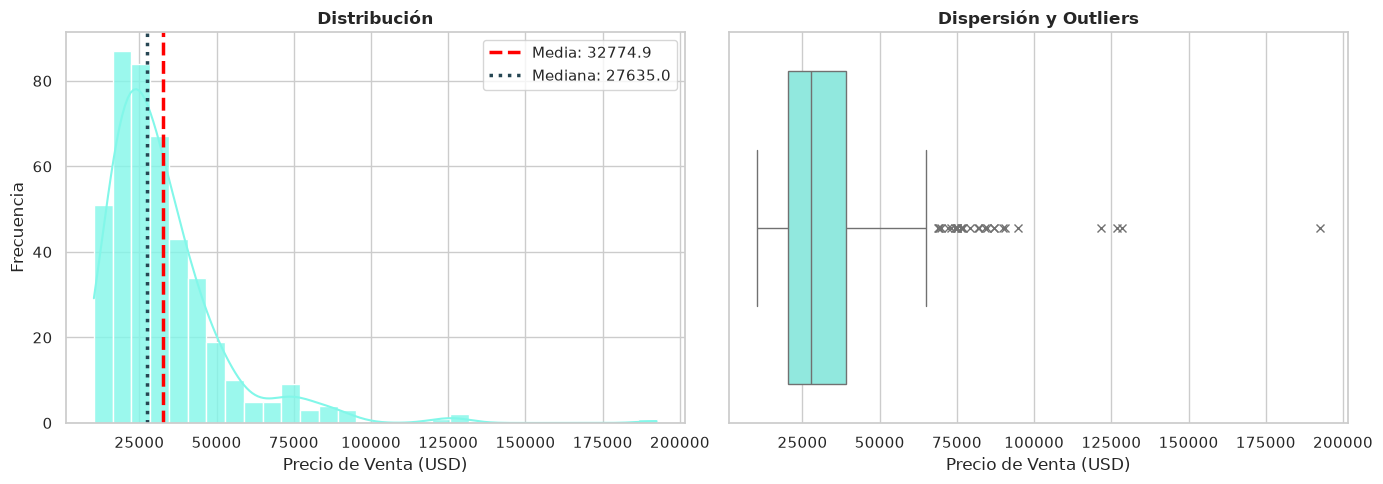

In [13]:
analizar_numerica(df, 'precio_venta', 'Precio de Venta (USD)')

En la variable **precio de venta**, se observa que la mayoría de los vehículos se concentra en valores relativamente bajos y medios, principalmente por debajo de los **50.000 USD**. La media es de **32.774,86 USD** y la mediana de **27.635 USD**, por lo que el promedio queda algo por encima del valor central.
También podemos observar la presencia de algunos vehículos con precios mucho más altos que el resto (outliers), llegando a valores cercanos a los **190.000 USD**. 



#### Variable **motor_litros**


--------------------------------------------------
 Análisis de: Cilindrada del Motor (Litros)
--------------------------------------------------


Métrica,Valor
Media,3.20
Mediana,3.00
Desv. Estándar,1.11
Cant. Outliers,2.00


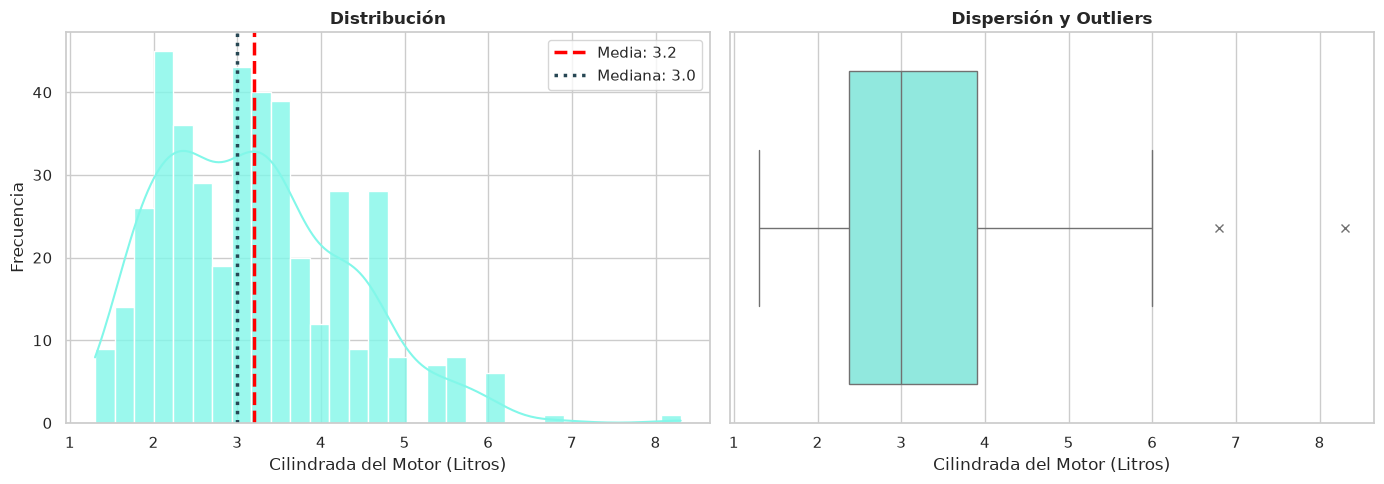

In [14]:
analizar_numerica(df, 'motor_litros', 'Cilindrada del Motor (Litros)')

En la variable **cilindrada del motor**, se observa que la mayoría de los vehículos se concentra entre aproximadamente **2 y 4 litros**. La media es de **3,20 litros** y la mediana de **3 litros**, por lo que no hay una diferencia importante entre ambas medidas. En general, la distribución muestra motores de cilindrada baja e intermedia, aunque aparecen algunos casos puntuales con valores más altos (superiores a 6 litros), diferenciándose del conjunto principal.


#### Variable **cilindros**


--------------------------------------------------
 Análisis de: Cantidad de Cilindros
--------------------------------------------------


Métrica,Valor
Media,5.79
Mediana,6.00
Desv. Estándar,1.58
Cant. Outliers,5.00


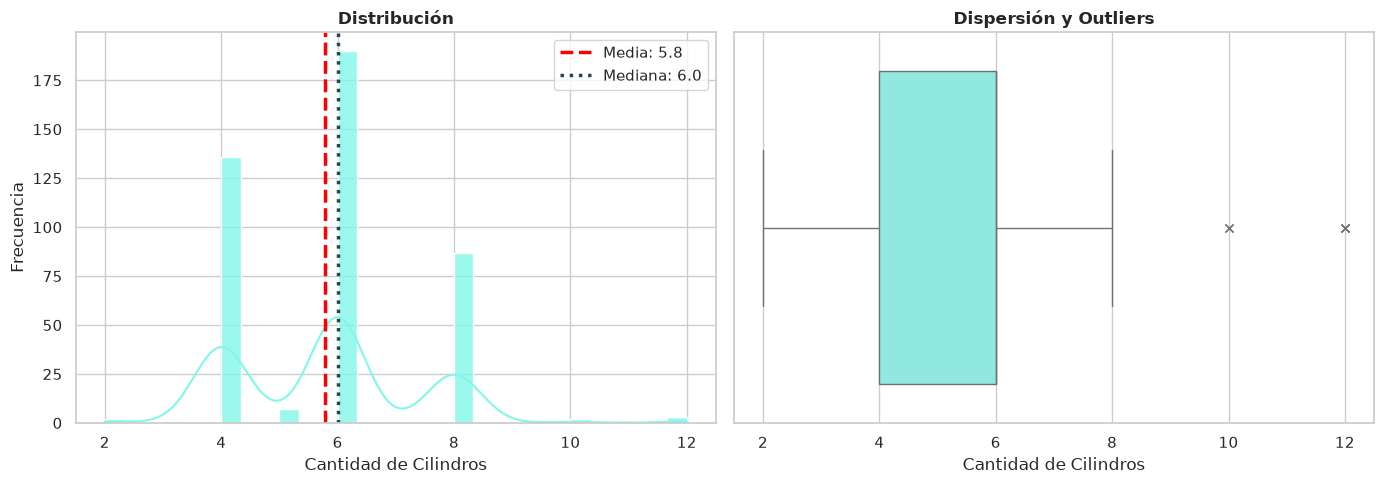

In [15]:
analizar_numerica(df, 'cilindros', 'Cantidad de Cilindros')

El comportamiento de la variable **Cantidad de cilindros** se ubica en torno a motores de cilindrada intermedia (4, 6 y 8 cilindros). Solo aparecen algunos casos puntuales con 10 y 12 cilindros, que se alejan del conjunto principal y representan vehículos con configuraciones menos frecuentes dentro del dataset.




#### Variable **caballos_fuerza**


--------------------------------------------------
 Análisis de: Potencia (Caballos de Fuerza)
--------------------------------------------------


Métrica,Valor
Media,215.89
Mediana,210.00
Desv. Estándar,71.84
Cant. Outliers,7.00


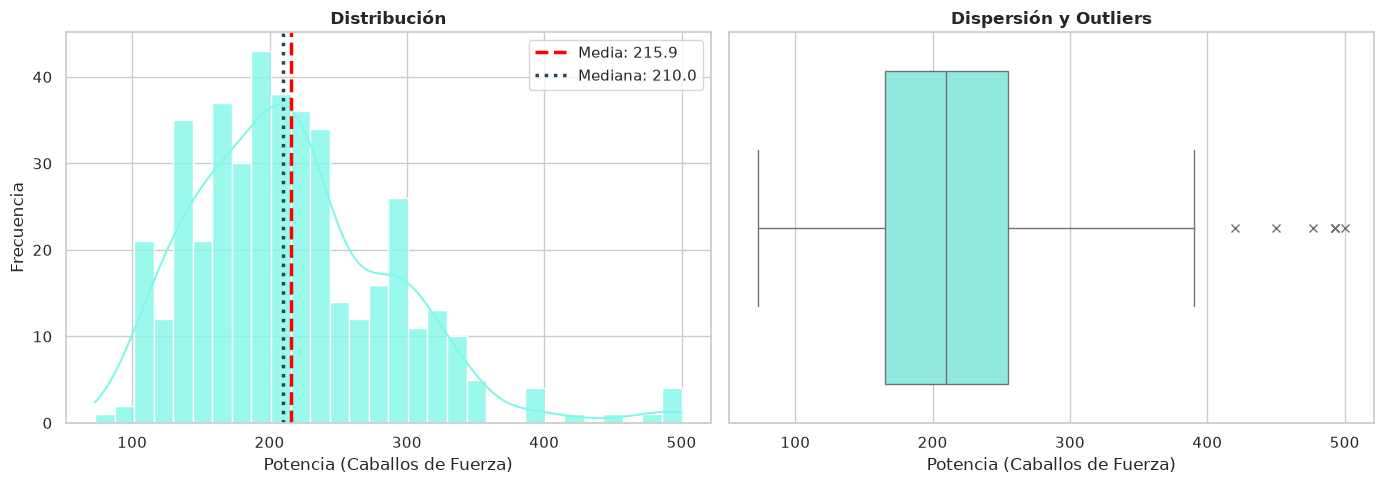

In [16]:
analizar_numerica(df, 'caballos_fuerza', 'Potencia (Caballos de Fuerza)')

En la variable **caballos de fuerza**, se observa que la mayoría de los vehículos se concentra aproximadamente entre **120 y 300 HP**. La media es de **215,89 HP** y la mediana de **210 HP**, por lo que ambas medidas son bastante cercanas. También podemos observar algunos vehículos con potencias muy superiores al resto, especialmente por encima de los **400 HP** y llegando cerca de los **500 HP**. Estos casos son pocos, pero se distinguen claramente del conjunto principal. 



#### Variable **rendimiento_ciudad_kmL**


--------------------------------------------------
 Análisis de: Rendimiento en Ciudad (km/L)
--------------------------------------------------


Métrica,Valor
Media,8.54
Mediana,8.10
Desv. Estándar,2.23
Cant. Outliers,30.00


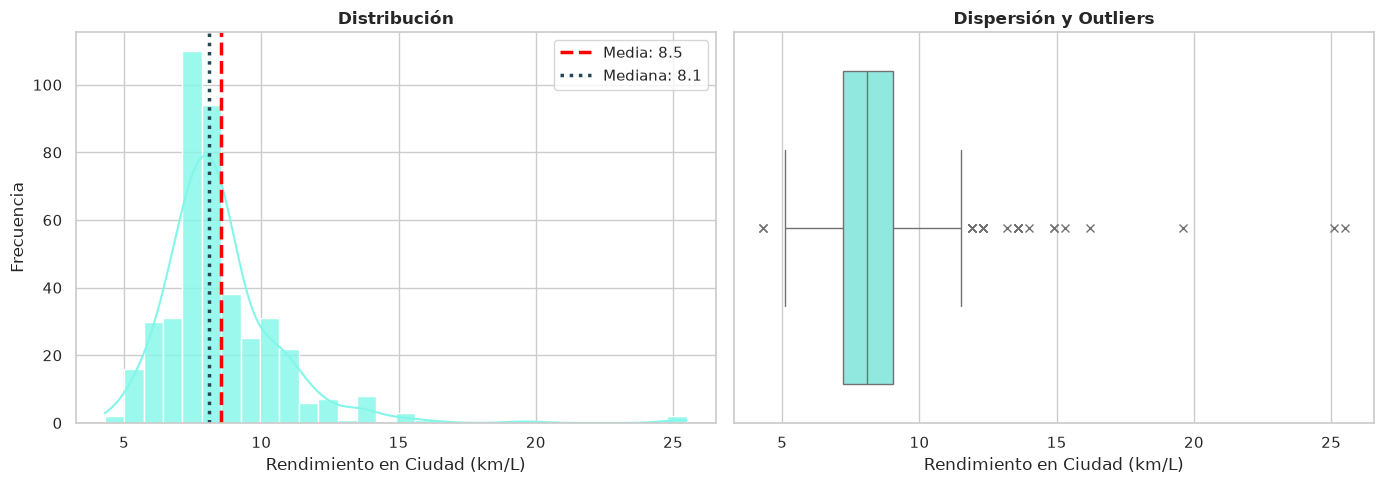

In [17]:
analizar_numerica(df, 'rendimiento_ciudad_kmL', 'Rendimiento en Ciudad (km/L)')

Teniendo en cuenta el **Rendimiento en ciudad** del auto, podemos observar que la mayoría de los autos se concentra entre 6 y 10 km/L, con una media de 8,54 km/L y una mediana de 8,10 km/L. Esto muestra que el comportamiento general de los vehículos se concentra en valores de consumo urbano moderados. También aparecen algunos casos que se alejan del comportamiento general. Por un lado, hay un vehículo con rendimiento bajo, cercano a los 5 km/L, lo que indica un mayor consumo de combustible. Por otro lado, se observan algunos autos con rendimientos superiores a los 20 km/L, que representan vehículos mucho más eficientes en ciudad.


#### Variable **rendimiento_ruta_kmL**


--------------------------------------------------
 Análisis de: Rendimiento en Ruta (km/L)
--------------------------------------------------


Métrica,Valor
Media,11.42
Mediana,11.10
Desv. Estándar,2.44
Cant. Outliers,24.00


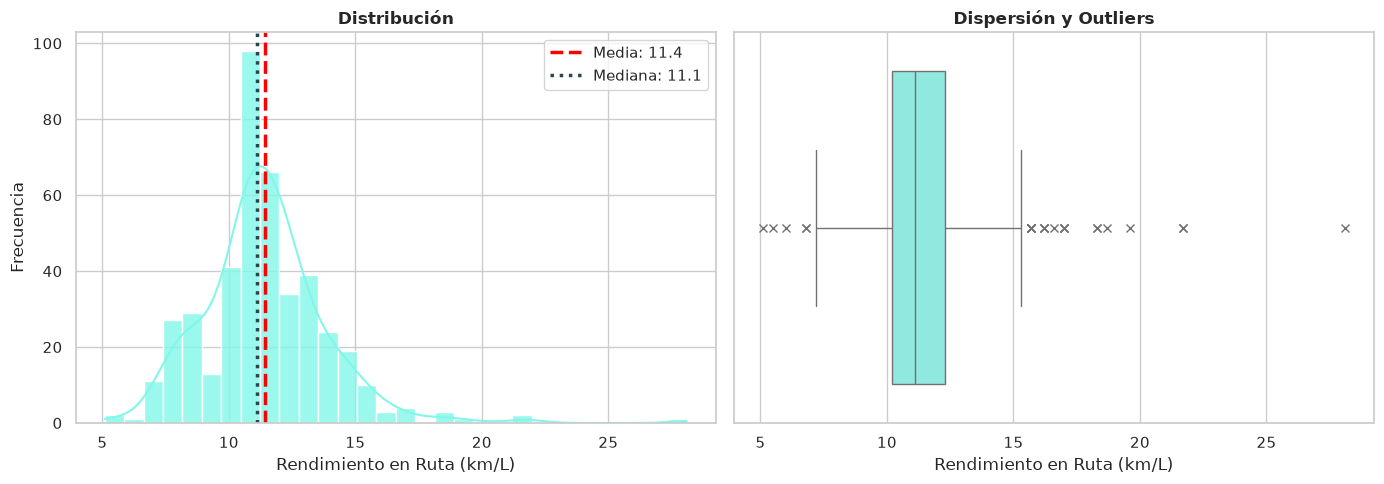

In [18]:
analizar_numerica(df, 'rendimiento_ruta_kmL', 'Rendimiento en Ruta (km/L)')

El **rendimiento en ruta** se concentra principalmente entre **9** y **14 km/L**, con una media de **11,42 km/L** y una mediana de **11,10 km/L**. Estos valores muestran que la mayoría de los vehículos presenta un rendimiento relativamente similar en condiciones de ruta. También se observan algunos casos que se alejan del comportamiento general, tanto con rendimientos bajos, cercanos a **5 km/L**, como con rendimientos superiores a los **20 km/L**.


#### Variable **peso_kg**


--------------------------------------------------
 Análisis de: Peso del Vehículo (kg)
--------------------------------------------------


Métrica,Valor
Media,1622.93
Mediana,1576.00
Desv. Estándar,344.27
Cant. Outliers,14.00


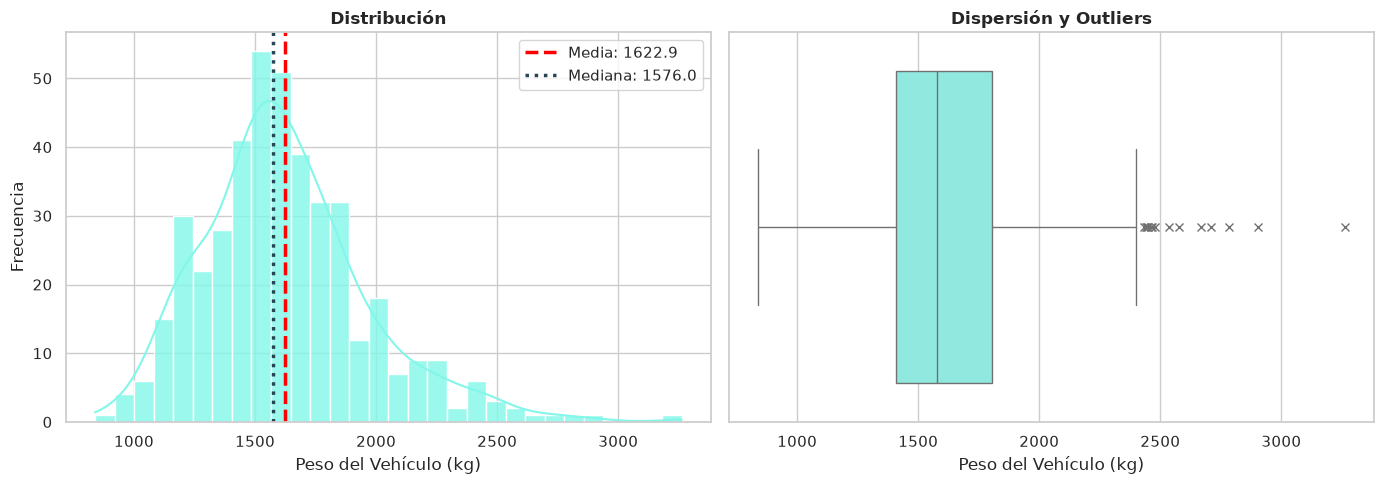

In [19]:
analizar_numerica(df, 'peso_kg', 'Peso del Vehículo (kg)')

El peso del vehículo se concentra principalmente entre **1.300** y **1.900 kg**. La media es de **1.622,93 kg** y la mediana de **1.576 kg**, por lo que ambos valores se ubican relativamente cerca. En el gráfico se observa que la mayoría de los autos tiene un peso intermedio, aunque aparecen algunos vehículos bastante más pesados, superando los **2.400 kg** e incluso acercándose a los **3.200 kg**.


#### Variable **distancia_ejes_cm**


--------------------------------------------------
 Análisis de: Distancia entre Ejes (cm)
--------------------------------------------------


Métrica,Valor
Media,274.71
Mediana,271.80
Desv. Estándar,21.11
Cant. Outliers,19.00


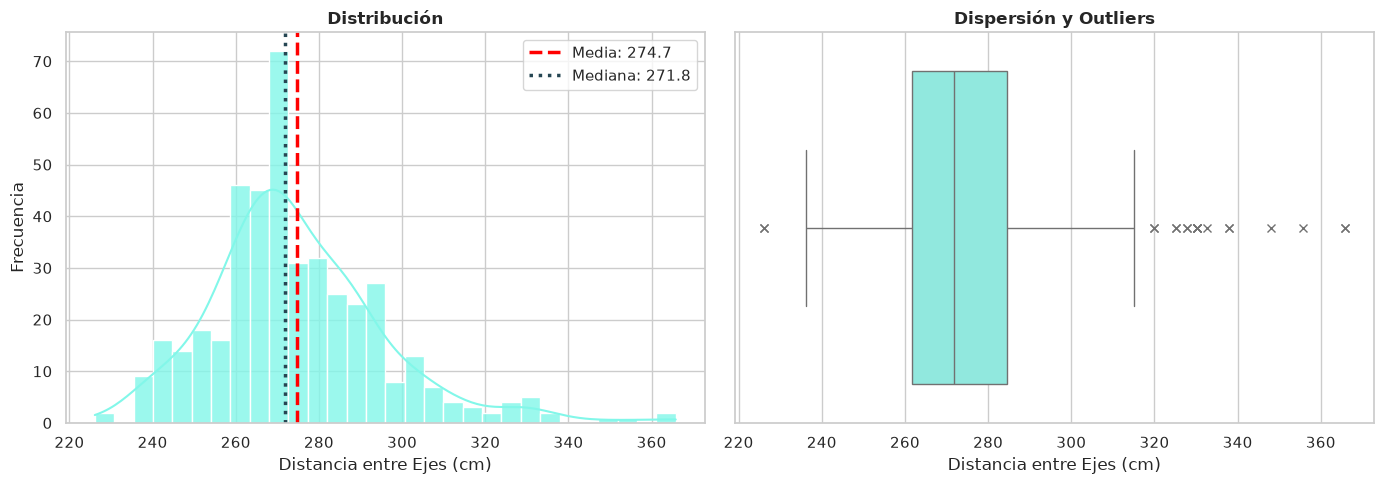

In [20]:
analizar_numerica(df, 'distancia_ejes_cm', 'Distancia entre Ejes (cm)')

La distancia entre ejes presenta valores concentrados principalmente entre 260 y 285 cm. La media es de 274,71 cm y la mediana de 271,80 cm, por lo que ambas medidas se encuentran bastante próximas. Podemos observar que la mayoría de los vehículos mantiene una distancia entre ejes similar, aunque aparecen algunos casos más alejados, especialmente por encima de los 320 cm. Estos valores corresponden a vehículos con una estructura más larga o de mayor tamaño.


#### Variable **largo_cm**


--------------------------------------------------
 Análisis de: Largo Total (cm)
--------------------------------------------------


Métrica,Valor
Media,473.36
Mediana,475.00
Desv. Estándar,36.47
Cant. Outliers,16.00


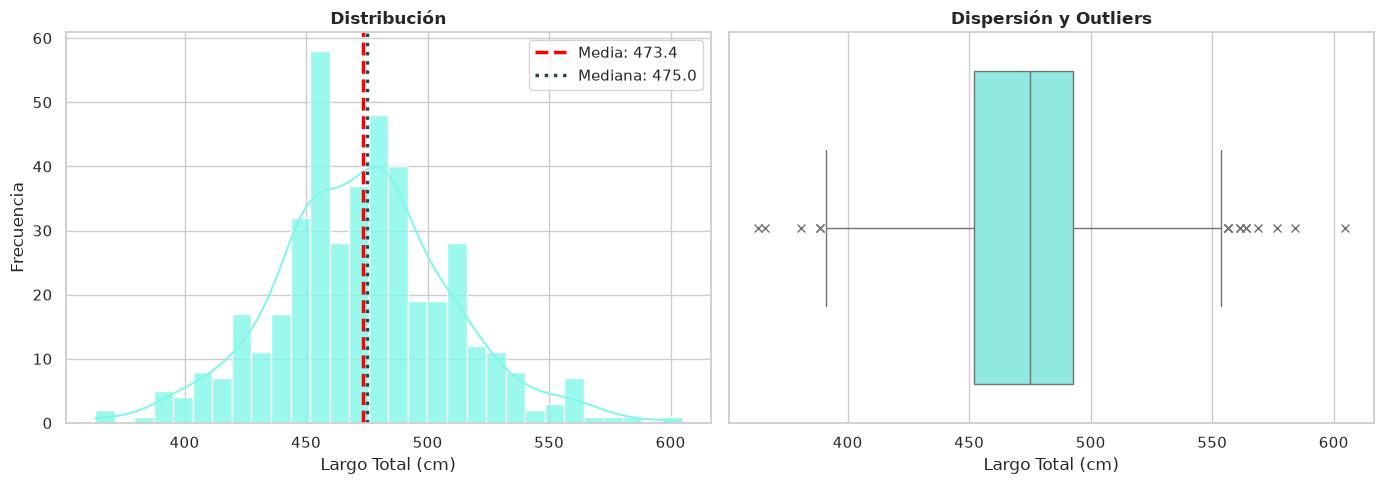

In [21]:
analizar_numerica(df, 'largo_cm', 'Largo Total (cm)')

El largo total del vehículo se concentra principalmente entre 450 y 500 cm. La media es de 473,36 cm y la mediana de 475 cm. En general, no se observa una diferencia muy marcada entre la mayoría de los vehículos, ya que gran parte de los autos se ubica alrededor del rango central. Sin embargo, aparecen algunos casos más alejados, tanto por debajo de los 400 cm (vehículos más cortos) como por encima de los 550 cm (vehículos más largos).


### Variables categóricas:

In [22]:
def analisis_univariado_categorico(df, columna, titulo_grafico, top_n=None):
    """
    Calcula tabla de frecuencias y grafica barras horizontales para variables categóricas.
    Diferenciado visualmente de las numéricas mediante colores cálidos.
    """
    # Filtrado opcional para no saturar el gráfico (ej: para la columna Marca)
    if top_n:
        orden = df[columna].value_counts().head(top_n).index
        df_plot = df[df[columna].isin(orden)]
        titulo_final = f'{titulo_grafico} (Top {top_n})'
    else:
        df_plot = df
        titulo_final = titulo_grafico

    # 1. Cálculos de frecuencia absoluta y relativa
    frecuencias = df_plot[columna].value_counts()
    porcentajes = df_plot[columna].value_counts(normalize=True) * 100
    
    # 2. Armado de la tabla profesional
    df_stats = pd.DataFrame({
        'Categoría': frecuencias.index,
        'Frecuencia Absoluta': frecuencias.values,
        'Frecuencia Relativa (%)': porcentajes.values
    })
    
    # Formateo visual de la tabla
    print(f"\n{'-'*50}\n Análisis de: {titulo_final}\n{'-'*50}")
    display(df_stats.style.format({'Frecuencia Relativa (%)': "{:.2f}%"}).hide(axis="index"))
    
    # 3. Gráfico de Barras Horizontales
    plt.figure(figsize=(10, 6))
    
    # Usamos la paleta 'magma' (cálida) para diferenciar de las numéricas
    ax = sns.barplot(
        x='Frecuencia Absoluta', 
        y='Categoría', 
        hue='Categoría', 
        data=df_stats, 
        palette='magma', 
        legend=False
    )
    
    # Agregamos la etiqueta del número exacto al final de cada barra
    for i, val in enumerate(frecuencias.values):
        ax.text(val + (val * 0.01), i, f'{val}', va='center', fontsize=10, fontweight='bold')
        
    plt.title(f'Distribución de {titulo_final}', fontsize=14, pad=10, fontweight='bold')
    plt.xlabel('Cantidad de Vehículos', fontsize=12) 
    plt.ylabel(titulo_grafico, fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Variable **tipo_vehiculo**


--------------------------------------------------
 Análisis de: Segmento del Vehículo
--------------------------------------------------


Categoría,Frecuencia Absoluta,Frecuencia Relativa (%)
Sedan,262,61.21%
SUV,60,14.02%
Sports,49,11.45%
Wagon,30,7.01%
Truck,24,5.61%
Hybrid,3,0.70%


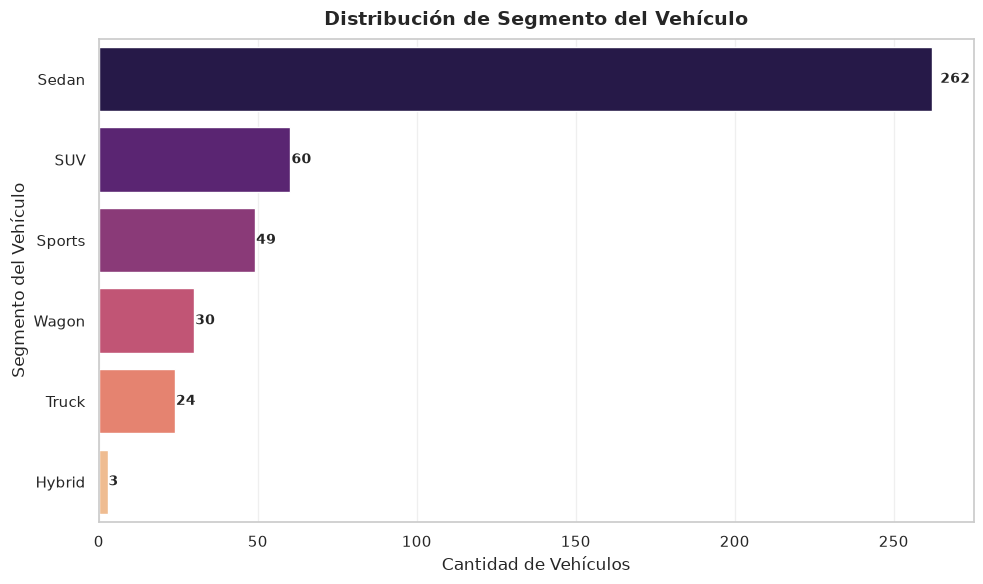

In [23]:
analisis_univariado_categorico(df, 'tipo_vehiculo', 'Segmento del Vehículo')

En la variable tipo de vehículo, se observa una diferencia marcada entre el segmento Sedan y el resto de las categorías. Los sedanes son los más frecuentes, con 262 vehículos, lo que representa el 61,21% del total. Las demás categorías aparecen con una participación mucho menor: SUV tiene 60 casos, Sports 49, Wagon 30 y Truck 24. La categoría menos representada es Hybrid, con solo 3 vehículos.





#### Variable **region_origen**


--------------------------------------------------
 Análisis de: Región de Fabricación
--------------------------------------------------


Categoría,Frecuencia Absoluta,Frecuencia Relativa (%)
Asia,158,36.92%
USA,147,34.35%
Europe,123,28.74%


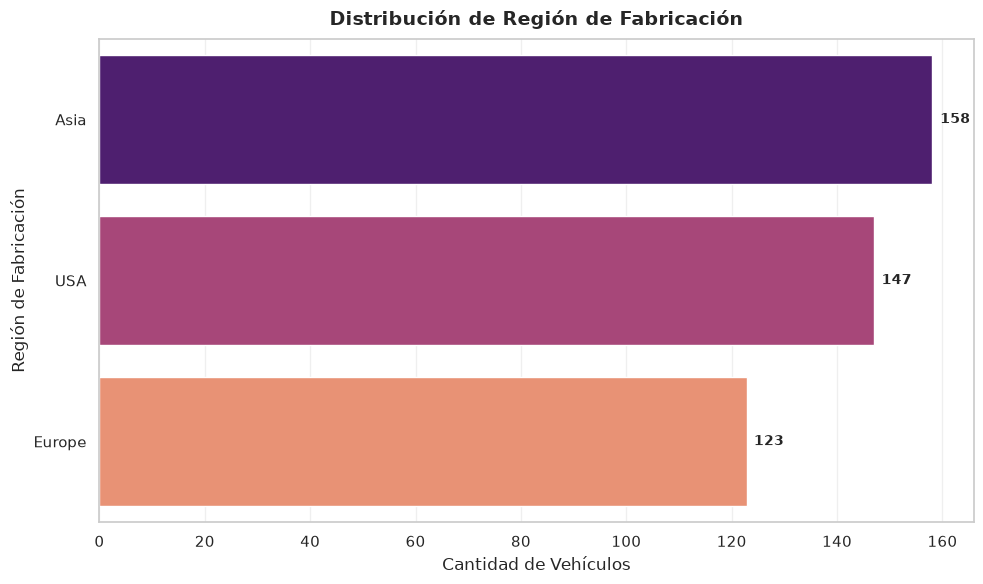

In [24]:
analisis_univariado_categorico(df, 'region_origen', 'Región de Fabricación')

En la variable **región de origen**, se observa una distribución bastante equilibrada entre las tres categorías. La región con mayor presencia es **Asia**, con **158 vehículos** (**36,92%**), seguida por **USA**, con **147 vehículos** (**34,35%**), y luego **Europa**, con **123 vehículos** (**28,74%**). A diferencia de otras variables categóricas, no hay una categoría que domine claramente sobre las demás. Si bien Asia aparece como la región más frecuente, la diferencia con USA es pequeña, y Europa también tiene una participación importante dentro del dataset.



#### Variable **traccion**


--------------------------------------------------
 Análisis de: Tipo de Tracción
--------------------------------------------------


Categoría,Frecuencia Absoluta,Frecuencia Relativa (%)
Front,226,52.80%
Rear,110,25.70%
All,92,21.50%


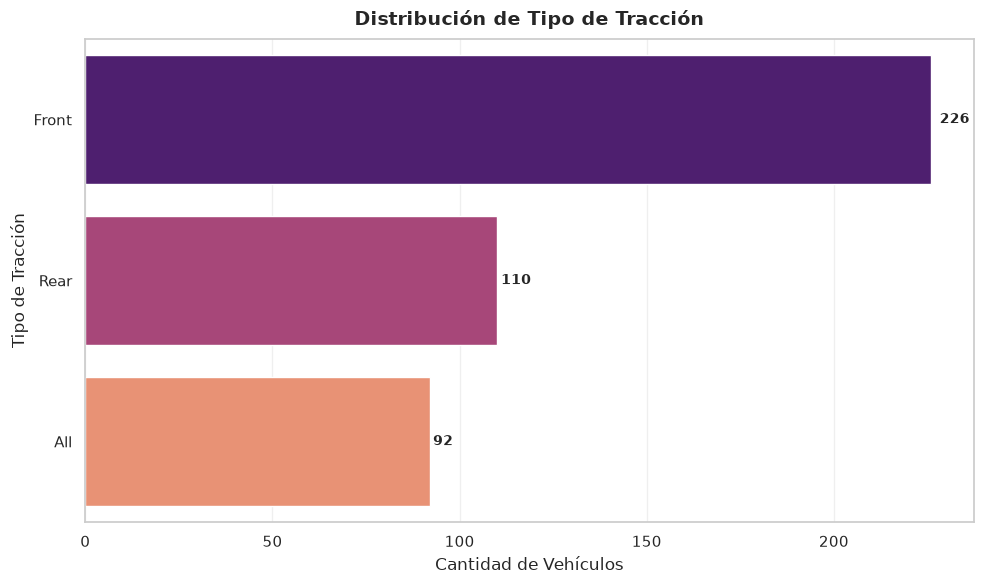

In [25]:
analisis_univariado_categorico(df, 'traccion', 'Tipo de Tracción')

En la variable tipo de tracción, se observa que la categoría más frecuente es Front, con 226 vehículos, representando el 52,80% del total. Esto indica que más de la mitad de los autos del dataset tienen tracción delantera. Las otras categorías aparecen con menor presencia: Rear cuenta con 110 vehículos (25,70%) y All con 92 vehículos (21,50%). Si bien ambas tienen una participación relevante, quedan bastante por debajo de la tracción delantera.


#### Variable **marca**


--------------------------------------------------
 Análisis de: Marcas de Vehículos (Top 10)
--------------------------------------------------


Categoría,Frecuencia Absoluta,Frecuencia Relativa (%)
Toyota,28,13.53%
Chevrolet,27,13.04%
Mercedes-Benz,26,12.56%
Ford,23,11.11%
BMW,20,9.66%
Audi,19,9.18%
Honda,17,8.21%
Nissan,17,8.21%
Chrysler,15,7.25%
Volkswagen,15,7.25%


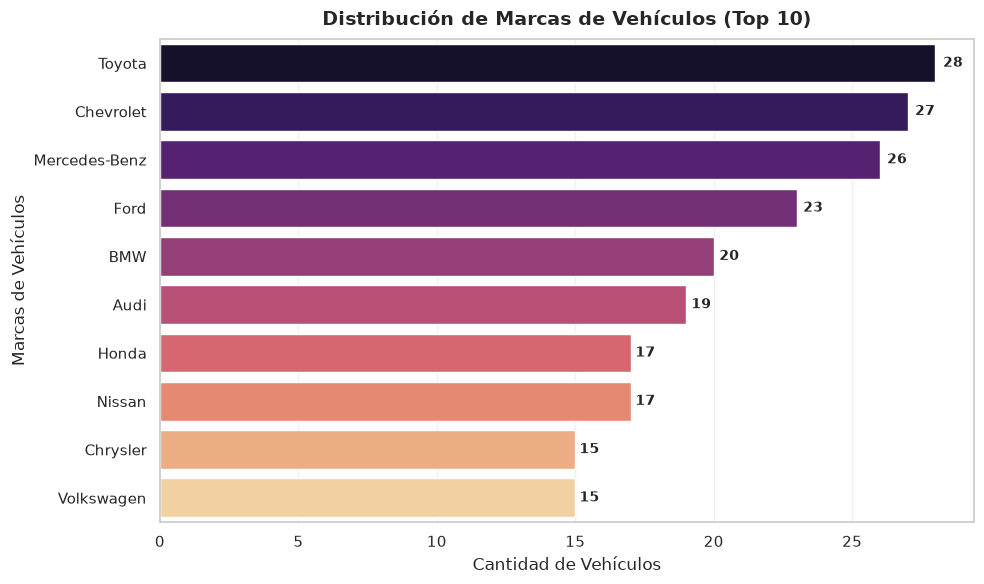

In [26]:
analisis_univariado_categorico(df, 'marca', 'Marcas de Vehículos', top_n=10)

Considerando las 10 marcas más frecuentes, se observa que la cantidad de vehículos por marca es bastante similar, ya que ninguna concentra una proporción muy superior al resto. Toyota aparece como la marca con mayor cantidad de vehículos, con 28 casos, seguida muy de cerca por Chevrolet con 27 y Mercedes-Benz con 26. Las marcas con menor presencia en este grupo son Chrysler y Volkswagen, ambas con 15 vehículos.


## Análisis Bivariado

####  Matriz de Dispersión (Pairplot)

Para evaluar el comportamiento conjunto de nuestras variables continuas, construimos una matriz de dispersión seleccionando los cinco indicadores más representativos del desempeño y valor del vehículo. El objetivo es identificar visualmente la existencia de correlaciones, tendencias y posibles agrupaciones naturales entre las variables antes de aplicar técnicas formales de reducción de dimensionalidad.

--- Generando Pairplot Bivariado ---


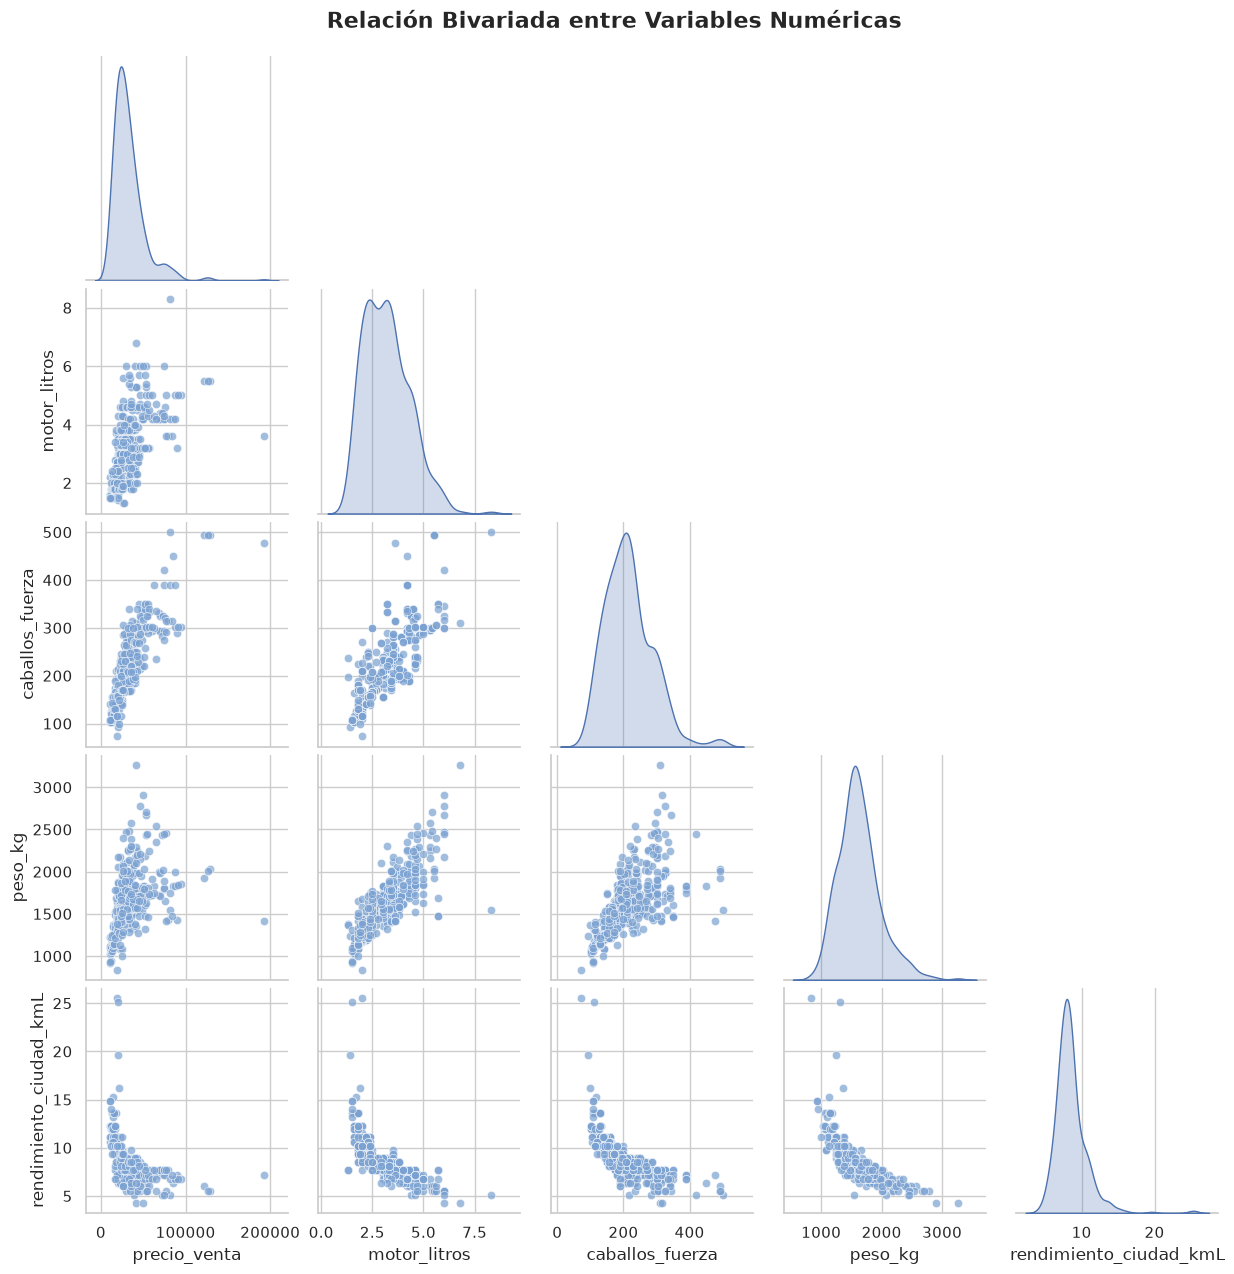

In [27]:
# Seleccionamos las 5 variables continuas clave para no saturar la visualización
columnas_bivariado = [
    'precio_venta', 
    'motor_litros', 
    'caballos_fuerza', 
    'peso_kg', 
    'rendimiento_ciudad_kmL'
]

print("--- Generando Pairplot Bivariado ---")

# Configuramos el estilo de fondo
sns.set_theme(style="whitegrid")

# Creamos el gráfico
pair_plot = sns.pairplot(
    df, 
    vars=columnas_bivariado, 
    diag_kind='kde', 
    plot_kws={'alpha': 0.7, 'edgecolor': 'white', 'color': "#7AA1D1"}, # Transparencia y bordes para distinguir puntos solapados
    corner=True 
)

pair_plot.fig.suptitle("Relación Bivariada entre Variables Numéricas", y=1.02, fontsize=16, fontweight='bold')
plt.show()

- Existe una correlación positiva muy fuerte entre el tamaño del motor (motor_litros), la potencia (caballos_fuerza) y el peso del auto (peso_kg). Es una relación física directa: los vehículos más pesados requieren motores más grandes, lo que inevitablemente genera más caballos de fuerza.

- Se observa una clara relación inversa entre el rendimiento en ciudad y las variables de potencia/tamaño. A medida que el motor, el peso y los caballos aumentan, la eficiencia de combustible cae en picada. Por el contrario, los picos de mayor rendimiento pertenecen exclusivamente a autos livianos y de motor chico (donde se encuentran los nichos híbridos).

- El precio de venta sube a medida que el auto tiene más potencia o un motor más grande, pero la relación se vuelve exponencial en los extremos. Los autos de gama estándar mantienen un crecimiento de precio predecible, pero al llegar a los vehículos de gama alta, los precios se disparan y se vuelven mucho más dispersos, reflejando el factor de "exclusividad" de ciertas marcas.

- Distribuciones asimétricas: Mirando los gráficos de la diagonal, todas las variables están sesgadas hacia la izquierda. Esto confirma que el volumen masivo del mercado se concentra en autos de precios bajos/medios, motores chicos y potencias estándar, mientras que los valores extremos (autos carísimos o súper potentes) son la minoría y forman esas "colas" largas hacia la derecha.

####  Matriz de Correlación Lineal (Pearson)

Para cuantificar las observaciones visuales de los diagramas de dispersión, calculamos la matriz de correlación de Pearson para nuestras variables numéricas. Confirmamos la existencia de correlaciones fuertes, tanto positivas (ej. tamaño del motor y caballos de fuerza) como negativas (ej. peso del vehículo y rendimiento en ciudad). 

La presencia de estas altas correlaciones lineales es la justificación matemática fundamental para aplicar técnicas multivariadas de reducción de dimensionalidad. Dado que las variables actuales contienen información redundante o fuertemente asociada, el Análisis de Componentes Principales (PCA) resultará altamente efectivo para condensar esta información en un número menor de dimensiones latentes.

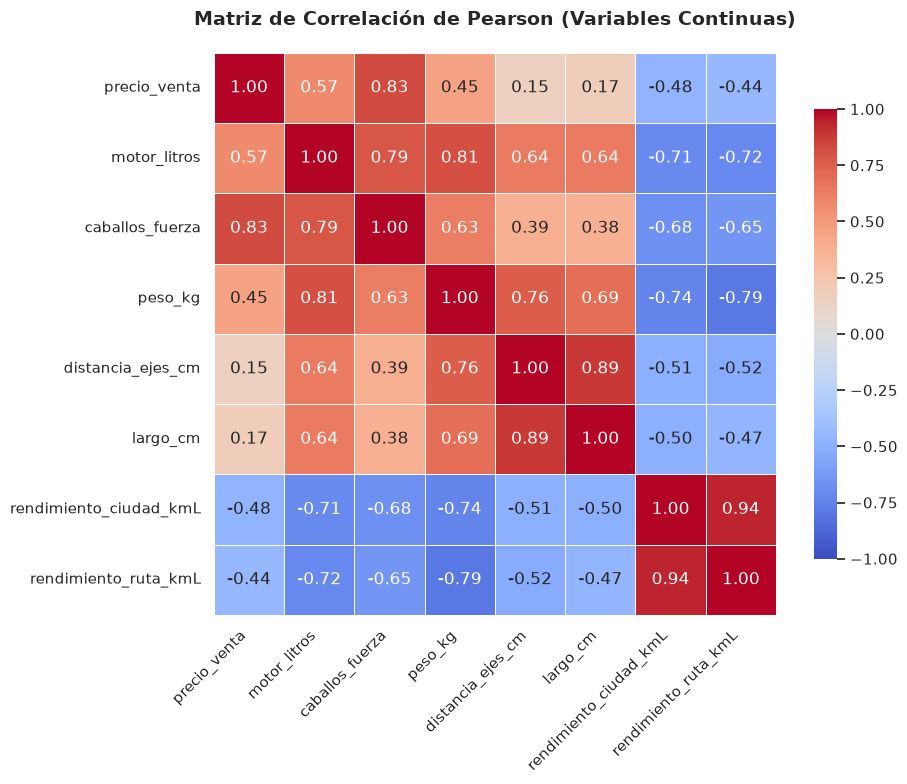

In [28]:
columnas_correlacion = [
    'precio_venta', 'motor_litros', 'caballos_fuerza', 
    'peso_kg', 'distancia_ejes_cm', 'largo_cm', 
    'rendimiento_ciudad_kmL', 'rendimiento_ruta_kmL'
]

matriz_corr = df[columnas_correlacion].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación de Pearson (Variables Continuas)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Correlaciones positivas fuertes: La matriz muestra asociaciones importantes entre variables relacionadas con el tamaño y el desempeño del vehículo. Por ejemplo, motor_litros se correlaciona fuertemente con caballos_fuerza $(r = 0,79)$ y con peso_kg $(r = 0,81)$. También se observa una relación alta entre distancia_ejes_cm y largo_cm $(r = 0,89)$, lo cual indica que ambas variables representan aspectos similares del tamaño estructural del vehículo.

- Relación entre precio y desempeño: El precio_venta presenta una correlación fuerte con caballos_fuerza $(r = 0,83)$, lo que muestra que los vehículos con mayor potencia tienden a tener precios más elevados. En cambio, la relación del precio con variables de tamaño, como peso_kg, distancia_ejes_cm y largo_cm, es más moderada o baja.

- Correlaciones negativas con el rendimiento: Las variables de rendimiento muestran una relación inversa con las variables asociadas al tamaño y la potencia. Por ejemplo, rendimiento_ciudad_kmL se correlaciona negativamente con peso_kg $(r = -0,74)$, motor_litros $(r = -0,71)$ y caballos_fuerza $(r = -0,68)$. Esto indica que los vehículos más pesados, con motores más grandes o más potentes, tienden a presentar menor eficiencia de consumo.

- Relación entre rendimientos: Se observa una correlación muy alta entre rendimiento_ciudad_kmL y rendimiento_ruta_kmL $(r = 0,94)$. Esto significa que los vehículos que tienen buen rendimiento en ciudad también suelen presentar buen rendimiento en ruta.

---

# Aplicación de Componentes Principales


### Selección de variables numéricas para la aplicación de componentes principales
Para la aplicación del Análisis de Componentes Principales, hemos seleccionado el conjunto completo de **9 variables numéricas** representativas del dataset:

* **Dimensión Comercial:** *precio_venta*
* **Capacidad Mecánica:** *motor_litros*, *cilindros*, *caballos_fuerza*
* **Eficiencia Energética:** *rendimiento_ciudad_kmL*, *rendimiento_ruta_kmL*
* **Estructura Física:** *peso_kg*, *distancia_ejes_cm*, *largo_cm*

La elección de este subconjunto se fundamenta en los hallazgos de la Matriz de Correlación de Pearson. El PCA es una técnica de reducción de dimensionalidad que se nutre de la covarianza; requiere que las variables originales estén correlacionadas para poder encontrar combinaciones lineales (componentes) que condensen la información. 

En nuestro Análisis Bivariado demostramos que estas 9 variables presentan fuertes asociaciones naturales (por ejemplo, el peso físico está altamente correlacionado con la cilindrada, y esta a su vez penaliza el rendimiento urbano). Al incluir este bloque integral, le proveemos al algoritmo la estructura matemática necesaria para descubrir dimensiones latentes (como el trade-off entre "Potencia y Eficiencia"), logrando reducir la complejidad del problema reteniendo la mayor cantidad de varianza posible.

*(Nota: La variable **cilindros**, si bien es de naturaleza discreta, posee una magnitud ordinal y métrica que refleja linealmente la escala del motor. Al ser estandarizada junto con las variables continuas, su inclusión en el PCA es estadísticamente válida y enriquece la captura de varianza).*

In [29]:
columnas_pca = [
    'precio_venta',           # Precio minorista sugerido (USD)
    'motor_litros',           # Cilindrada del motor (Litros)
    'cilindros',              # Cantidad de cilindros o rotores
    'caballos_fuerza',        # Potencia máxima
    'rendimiento_ciudad_kmL', # Eficiencia de combustible en ciudad (km/L)
    'rendimiento_ruta_kmL',   # Eficiencia de combustible en ruta (km/L)
    'peso_kg',                # Peso físico del vehículo (kg)
    'distancia_ejes_cm',      # Distancia entre el eje delantero y trasero (cm)
    'largo_cm'                # Longitud total de paragolpes a paragolpes (cm)
]

###  Estandarización de las variables

En nuestro dataset automotor, las variables seleccionadas operan en escalas y unidades de medida radicalmente diferentes:
* **Precio de Venta (`precio_venta`):** Valores numéricos grandes, frecuentemente en el orden de las decenas o cientos de miles de dólares.
* **Cilindrada (`motor_litros`):** Valores pequeños, típicamente comprendidos entre 1 y 8 litros.

Si no estandarizamos la matriz de datos, el algoritmo de Componentes Principales le otorgará artificialmente mayor importancia a variables como `precio_venta` o `peso_kg` simplemente porque poseen una magnitud mayor y, por ende, aportan más varianza absoluta. Esto causaría que las componentes latentes sean dominadas casi en su totalidad por las dimensiones de costo y masa, ignorando por completo la valiosa información de rendimiento y motorización.

Es por ello que aplicamos una estandarización (tipo `StandardScaler`), la cual transforma cada observación $x$ mediante la siguiente fórmula: 

$$z = \frac{x - \bar{x}}{s}$$

Donde:
* $x$: Es el valor original de la observación.
* $\bar{x}$: Es la media aritmética de la variable.
* $s$: Es la desviación estándar de la variable.

Tras este proceso matemático, todas nuestras variables pasarán a tener una media igual a 0 y una desviación estándar igual a 1. De esta manera, el PCA podrá identificar las verdaderas relaciones estructurales entre los atributos técnicos y comerciales basándose exclusivamente en sus correlaciones, neutralizando el sesgo de sus respectivas unidades de medida.

In [30]:
X = df[columnas_pca].fillna(0)

#Estandarización (media 0, desvío 1)
scaler = StandardScaler()
Z = scaler.fit_transform(X)

### Aplicamos PCA a los datos estandarizados

In [31]:
pca = PCA()
pca.fit(Z)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Métricas claves
En esta etapa, evaluamos la eficiencia del modelo para condensar la información original. El objetivo es identificar la cantidad óptima de componentes necesarios para representar la variabilidad del dataset.

In [32]:
autovalores = pca.explained_variance_
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

resumen_pca = pd.DataFrame({
    'Componente': [f'CP{i}' for i in range(1, len(autovalores) + 1)],
    'Autovalor': autovalores,
    'Varianza Explicada (%)': var_explicada,
    'Varianza Acumulada (%)': var_acumulada
})

print("\n--- TABLA DE VARIANZA EXPLICADA Y AUTOVALORES ---")
display(resumen_pca.round(2))


--- TABLA DE VARIANZA EXPLICADA Y AUTOVALORES ---


,Componente,Autovalor,Varianza Explicada (%),Varianza Acumulada (%)
0,CP1,6.07,67.32,67.32
1,CP2,1.40,15.52,82.85
2,CP3,0.71,7.85,90.70
3,CP4,0.31,3.40,94.10
4,CP5,0.21,2.30,96.40
5,CP6,0.13,1.39,97.79
6,CP7,0.09,0.99,98.78
7,CP8,0.07,0.76,99.54
8,CP9,0.04,0.46,100.00


### Gráfico Scree

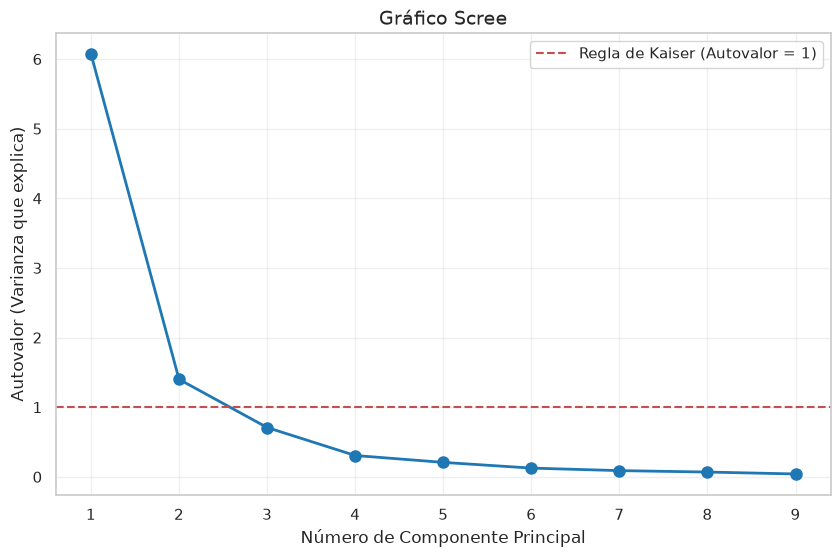

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(autovalores) + 1), autovalores, marker='o', linewidth=2, markersize=8, color='#1f77b4')

# Línea roja para la Regla de Kaiser (Autovalor = 1)
plt.axhline(y=1, color='r', linestyle='--', label='Regla de Kaiser (Autovalor = 1)')

plt.title('Gráfico Scree', fontsize=14)
plt.xlabel('Número de Componente Principal', fontsize=12)
plt.ylabel('Autovalor (Varianza que explica)', fontsize=12)
plt.xticks(range(1, len(autovalores) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Selección del número de componentes principales para el análisis
Para determinar el número óptimo de componentes principales a retener para realizar el análisis, utilizaremos tres criterios estadísticos fundamentales:
- **Criterio de (Autovalores > 1)**: Este criterio sugiere retener todas aquellas componentes cuyo autovalor sea mayor a 1. En nuestra tabla podemos observar que CP1(6.07) y CP2(1.4) son las únicas CP que superan este umbral. Según este criterio, deberíamos conservar 2 componentes.

- **Criterio de la varianza acumulada**: Este criterio sugiere retener un número de componentes que en conjunto expliquen un porcentaje satisfactorio de la varianza total (entre el 75% y 85%). 
Observando nuevamente la tabla, reteniendo únicamente las primeras dos componentes principales logramos acumular el 82,85% de la información original. Si decidiéramos retener 3 componentes, llegaríamos a acumular el 90,7% de la información original.

- **Criterio del codo (gráfico Scree)**: Visualmente, buscamos el codo donde la caída se suaviza. Es un autovalor tal que a su izquierda el segmento recto sea empinado y a su derecha sea más horizontal.
Podemos observar que el codo se encuentra en la CP2, donde a su izquierda tenemos el segmento empinado, y a su derecha el segmento se vuelve más horizontal. Dado este criterio, nos estaríamos quedando únicamente con la CP1.

**Conclusión**: considerando los tres criterios mencionados y analizados, determinamos que el número óptimo de componentes principales a retener es 2, es decir, trabajaremos con la CP1 y la CP2.

### Interpretación y estructura de las componentes CP1 y CP2
Para analizar la estructura subyacente de cada componente, nos basaremos en dos herramientas fundamentales:
- **Tabla de Pesos (Loadings)**: Representan la correlación entre las variables originales y cada componente principal. Nos permiten identificar no solo la fuerza de la relación, sino también su dirección (signo).
                (Un peso positivo alto indica que la variable aumenta con la componente; un peso negativo indica una relación inversa.)

- **Gráfico de Contribuciones**: Esta visualización transforma los pesos en porcentajes para determinar cuánta "energía" aporta cada variable a la formación de la componente. Es fundamental para separar las variables que realmente definen el eje de aquellas que solo aportan "ruido" estadístico.

### Tabla de Coeficientes (Autovectores)

In [34]:
# 1. Extraer las cargas (loadings) del modelo PCA
# pca.components_ tiene los pesos matemáticos de cada variable
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'CP{i}' for i in range(1, len(columnas_pca) + 1)],
    index=columnas_pca
)

# Filtramos la tabla para mostrar solo las primeras 2 componentes.
componentes_a_retener = ['CP1', 'CP2']
loadings_reducido = loadings[componentes_a_retener]

# ==========================================
# 2. TABLA INTERACTIVA DE LOADINGS
# ==========================================
print("--- PESO DE LAS VARIABLES EN CADA COMPONENTE ---")

# Aplicamos un gradiente de color para identificar la importancia visualmente
# axis=0 compara los pesos dentro de cada columna (componente)
loadings_estilizado = loadings_reducido.style.background_gradient(
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1
).format("{:.3f}")

display(loadings_estilizado)

--- PESO DE LAS VARIABLES EN CADA COMPONENTE ---


,CP1,CP2
precio_venta,0.258,0.544
motor_litros,0.377,0.030
cilindros,0.362,0.141
caballos_fuerza,0.339,0.372
rendimiento_ciudad_kmL,-0.347,-0.054
rendimiento_ruta_kmL,-0.346,-0.030
peso_kg,0.367,-0.165
distancia_ejes_cm,0.296,-0.515
largo_cm,0.289,-0.499


### Ecuaciones Lineales de las Componentes Principales

Cada componente principal se construye como una combinación lineal de las variables originales previamente estandarizadas. Los coeficientes (pesos) determinan la magnitud y dirección (positiva o negativa) del aporte de cada variable a la nueva dimensión.

**Ecuación para la Componente Principal 1 (Tamaño y Potencia vs. Eficiencia):**
$$CP1 = 0.258 \cdot \text{precio\_venta} + 0.377 \cdot \text{motor\_litros} + 0.362 \cdot \text{cilindros} + 0.339 \cdot \text{caballos\_fuerza} - 0.347 \cdot \text{rendimiento\_ciudad\_kmL} - 0.346 \cdot \text{rendimiento\_ruta\_kmL} + 0.367 \cdot \text{peso\_kg} + 0.296 \cdot \text{distancia\_ejes\_cm} + 0.289 \cdot \text{largo\_cm}$$

**Ecuación para la Componente Principal 2 (Exclusividad y Deportividad vs. Volumen Familiar):**
$$CP2 = 0.544 \cdot \text{precio\_venta} + 0.030 \cdot \text{motor\_litros} + 0.141 \cdot \text{cilindros} + 0.372 \cdot \text{caballos\_fuerza} - 0.054 \cdot \text{rendimiento\_ciudad\_kmL} - 0.030 \cdot \text{rendimiento\_ruta\_kmL} - 0.165 \cdot \text{peso\_kg} - 0.515 \cdot \text{distancia\_ejes\_cm} - 0.499 \cdot \text{largo\_cm}$$

### Gráfico de cargas

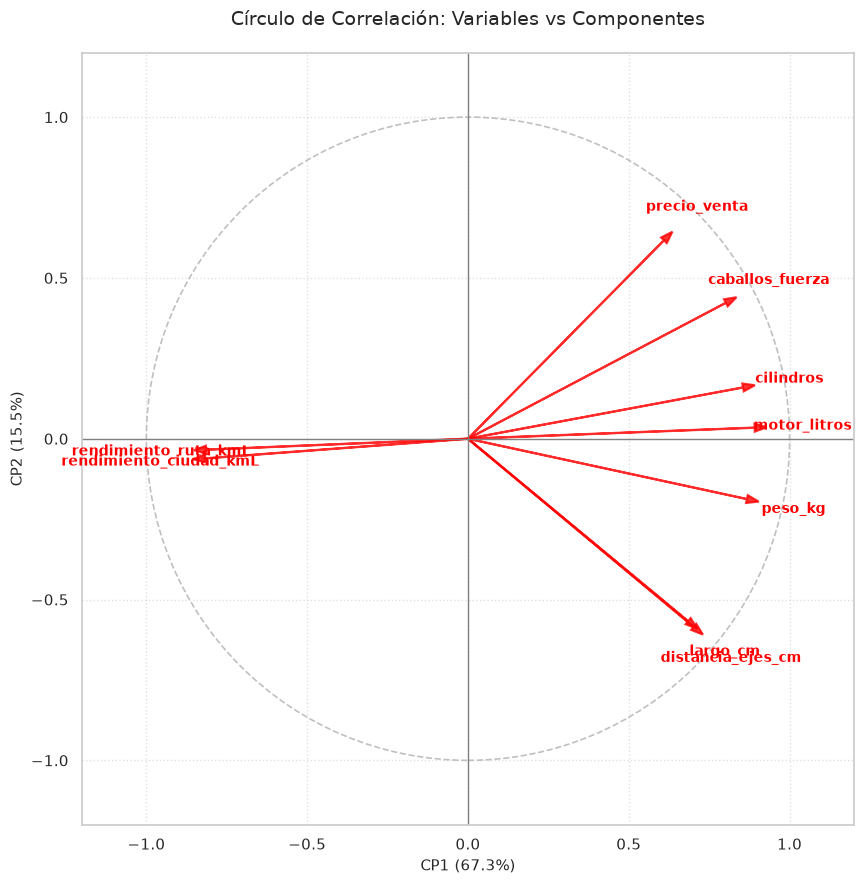

In [35]:
cargas = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))

# Circulo unitario (un poco mas sutil)
circulo = plt.Circle((0, 0), 1, fill=False, color='silver', linestyle='--', linewidth=1.2)
ax.add_artist(circulo)

ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)

# Colores para distinguir si queremos, o uno solo profesional
color_flecha = "#ff0000" 
color_texto = "#ff0000"

for i in range(cargas.shape[0]):
    # Dibujamos la flecha
    ax.arrow(0, 0, cargas[i, 0], cargas[i, 1], 
             color=color_flecha, alpha=0.8, head_width=0.025, 
             length_includes_head=True, linewidth=1.5)
    
    ax.text(cargas[i, 0] * 1.12, cargas[i, 1] * 1.12, 
            columnas_pca[i], color=color_flecha, 
            fontweight='bold', ha='center', va='center', fontsize=10)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f"CP1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=11)
ax.set_ylabel(f"CP2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=11)
ax.set_title("Círculo de Correlación: Variables vs Componentes", fontsize=14, pad=20)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

**Análisis del Círculo de Correlación (CP1 vs CP2)**

El gráfico confirma la excelente calidad de la reducción dimensional, ya que la práctica totalidad de los vectores alcanzan o se acercan significativamente a la periferia del círculo unitario. Esto indica que la información y variabilidad de las variables originales están magníficamente representadas en este plano bidimensional.

- **El "Trade-off" Mecánico y Físico (CP1):**

   El eje horizontal (CP1, 67.3% de la varianza) revela la dicotomía principal del diseño automotriz mediante dos grupos vectoriales diametralmente opuestos:

   Hacia la derecha (Positivo): Se observa un fuerte racimo compuesto por motor_litros, cilindros, peso_kg y caballos_fuerza. Esto demuestra una altísima correlación positiva entre el tamaño físico del bloque del motor, la masa del vehículo y la potencia entregada.

   Hacia la izquierda (Negativo): Se ubican en solapamiento casi perfecto rendimiento_ciudad_kmL y rendimiento_ruta_kmL.


- **El Posicionamiento Comercial y Estructural (CP2):**

   El eje vertical (CP2, 15.5% de la varianza) revela cómo se estructuran las dimensiones físicas respecto al valor de mercado, separando a los vehículos en dos polos:

   Hacia arriba (Positivo): Destaca fuertemente el precio_venta, acompañado por caballos_fuerza. Los vehículos que suben en este eje tienden a ser mucho más costosos y de perfil deportivo o premium.

   Hacia abajo (Negativo): Se agrupan fuertemente las variables de envergadura longitudinal, específicamente distancia_ejes_cm y largo_cm.

### Gráfico de contribuciones

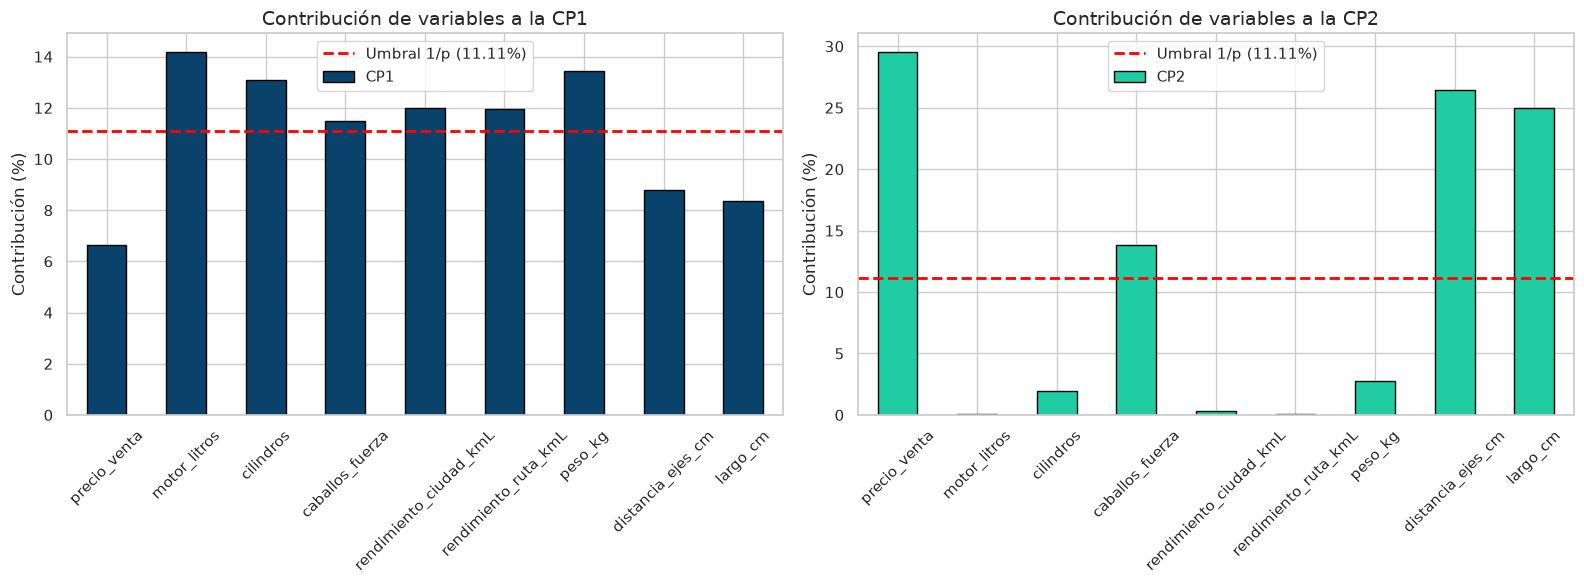

--- TABLA DE CONTRIBUCIONES (%) | Umbral: 11.11% ---


,CP1,CP2
precio_venta,6.65,29.57
motor_litros,14.20,0.09
cilindros,13.10,1.98
caballos_fuerza,11.48,13.83
rendimiento_ciudad_kmL,12.01,0.29
rendimiento_ruta_kmL,11.94,0.09
peso_kg,13.45,2.73
distancia_ejes_cm,8.79,26.47
largo_cm,8.38,24.95


In [36]:
# 1. Calculamos las contribuciones al cuadrado de los autovectores (loadings)
contribuciones = pd.DataFrame(
    (pca.components_.T ** 2) * 100, 
    columns=[f'CP{i}' for i in range(1, len(columnas_pca) + 1)],
    index=columnas_pca
)

# 2. Calculamos el umbral 1/p (100% dividido por la cantidad de variables)
p = len(columnas_pca)
umbral = 100 / p

# ==========================================
# 3. GRÁFICOS DE CONTRIBUCIÓN PARA EL INFORME
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para CP1
contrib_cp1 = contribuciones['CP1']
contrib_cp1.plot(kind='bar', color="#09436c", edgecolor='black', ax=axes[0])
axes[0].axhline(y=umbral, color='red', linestyle='--', linewidth=2, label=f'Umbral 1/p ({umbral:.2f}%)')
axes[0].set_title('Contribución de variables a la CP1', fontsize=14)
axes[0].set_ylabel('Contribución (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Gráfico para CP2
contrib_cp2 = contribuciones['CP2']
contrib_cp2.plot(kind='bar', color="#20cda2", edgecolor='black', ax=axes[1])
axes[1].axhline(y=umbral, color='red', linestyle='--', linewidth=2, label=f'Umbral 1/p ({umbral:.2f}%)')
axes[1].set_title('Contribución de variables a la CP2', fontsize=14)
axes[1].set_ylabel('Contribución (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


print(f"--- TABLA DE CONTRIBUCIONES (%) | Umbral: {umbral:.2f}% ---")
def color_umbral(val):
    color = '#d4edda' if val > umbral else 'white'
    return f'background-color: {color}'
display(
    contribuciones[['CP1', 'CP2']]
    .style
    .format("{:.2f}")
    .map(color_umbral)
)

**Componente Principal 1 (CP1 - 67.3%): "Tamaño y Potencia vs. Eficiencia"**

Las seis variables puramente mecánicas y de rendimiento (motor_litros, cilindros, caballos_fuerza, rendimiento_ciudad_kmL, rendimiento_ruta_kmL y peso_kg) superan holgadamente el umbral. Esto ratifica que la primera componente es una dimensión estrictamente técnica que ignora por completo el factor económico y las dimensiones espaciales del chasis.

<u>Interpretación</u>: Un vehículo que tome valores positivos en CP1 será un automóvil pesado, con motor grande y muy potente, pero con un alto consumo de combustible (como una SUV grande o un Muscle Car). Por el contrario, los vehículos que tomen valores negativos en CP1 son autos livianos, de motor pequeño y alta eficiencia urbana.

**Componente Principal 2 (CP2 - 15.5%): "Exclusividad y Deportividad vs. Volumen Familiar"**

Las variables que dominan esta componente son el precio_venta (aportando casi un 30% de la información del eje), seguido por distancia_ejes_cm, largo_cm y caballos_fuerza. Esto confirma que la CP2 es una dimensión comercial y de formato estructural, que abstrae el consumo o el tamaño del motor para enfocarse en la exclusividad y la envergadura del vehículo.

<u>Interpretación</u>: Un valor muy alto en CP2 indica vehículos sumamente costosos y potentes, pero que no destacan por ser excesivamente largos (característico de los autos deportivos de lujo o convertibles). En contraposición, un valor bajo en CP2 describe vehículos muy largos y con gran distancia entre ejes, pero de precios más accesibles e inferior potencia (típico perfil de minivans, vehículos familiares de pasajeros o sedanes largos tradicionales).

### Gráfico Scores

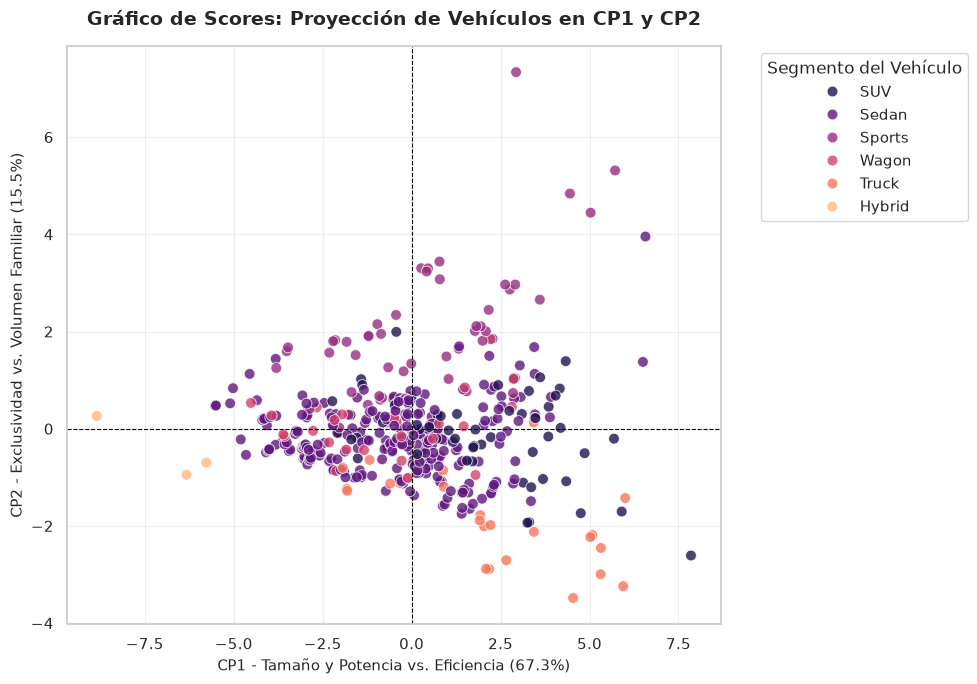

In [37]:
# 1. Calculamos los scores
scores = pca.transform(Z)

df_scores = pd.DataFrame(
    scores[:, :2], 
    columns=['CP1', 'CP2'],
    index=df.index 
)

df_scores['tipo_vehiculo'] = df['tipo_vehiculo']

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_scores, 
    x='CP1', 
    y='CP2', 
    hue='tipo_vehiculo', 
    palette='magma',    
    alpha=0.8,           
    s=60,              
    edgecolor='white'
)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.title('Gráfico de Scores: Proyección de Vehículos en CP1 y CP2', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'CP1 - Tamaño y Potencia vs. Eficiencia ({resumen_pca.iloc[0,2]:.1f}%)', fontsize=11)
plt.ylabel(f'CP2 - Exclusividad vs. Volumen Familiar ({resumen_pca.iloc[1,2]:.1f}%)', fontsize=11)

plt.legend(title='Segmento del Vehículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- #### Interpretación de la Proyección de Individuos (Score Plot)

   Aunque el centro del gráfico presenta cierta superposición natural propia de la estandarización de la industria automotriz, el análisis de los extremos del plano de componentes revela agrupaciones altamente coherentes con la realidad comercial y mecánica de los distintos segmentos:

   * **Híbridos (Extremo Izquierdo):** Los puntos de color durazno (`Hybrid`) se aíslan en el sector más negativo de la CP1. Esto valida nuestra interpretación anterior: son los vehículos de máxima eficiencia de combustible, motores pequeños y bajo peso, situándose cerca del centro en la CP2 debido a su formato de dimensiones estándar.
   * **Deportivos (Cuadrante Superior Derecho):** Los puntos fucsias (`Sports`) dominan la parte alta del gráfico. Combinan un alto tamaño de motor y potencia (CP1 positivo) con el máximo nivel de precios y exclusividad (CP2 altamente positivo). Se observa incluso un valor atípico extremo en la parte superior, que seguramente representa un vehículo de lujo de altísima gama.
   * **Camionetas / Trucks (Cuadrante Inferior Derecho):** Los puntos color salmón (`Truck`) se concentran en el sector inferior derecho. Esto describe matemáticamente a vehículos muy pesados y potentes (CP1 positivo), pero con chasis extremadamente largos y gran distancia entre ejes, priorizando el volumen utilitario sobre el valor de exclusividad por marca (CP2 negativo).
   * **Sedanes y SUVs (El Centro de Masa):** Los `Sedan` representan el "estándar" del mercado, agrupándose mayoritariamente alrededor del origen de coordenadas (0,0). Por su parte, las `SUVs` presentan una leve tendencia hacia la derecha (mayor peso y motor que un sedán) pero comparten el centro comercial del gráfico, evidenciando su diversidad de tamaños y precios en el mercado actual.

### Identificación de Valores Atípicos (Outliers)

En esta sección, aislamos y analizamos las observaciones que presentan un comportamiento extremo en el nuevo plano de componentes principales. A partir de la inspección visual del *Score Plot*, identificamos registros que se alejan drásticamente del centro de masa del dataset, particularmente superando umbrales estadísticos de desviación en ambas componentes. 

El objetivo de este análisis no es considerar a estos registros como 'datos ruidosos' para ser descartados, sino comprender la naturaleza de estas configuraciones excepcionales. En el contexto automotor, estos *outliers* suelen representar vehículos hiper-deportivos de producción limitada, sedanes de ultra-lujo o plataformas con motorizaciones atípicas. Si bien son una minoría absoluta en el volumen del mercado, representan el pináculo de la ingeniería de sus respectivas marcas y justifican su aislamiento matemático del resto de los segmentos tradicionales.

In [38]:
outliers_extremos = df_scores[df_scores['CP2'] > 6]

columnas_a_mostrar = ['marca', 'modelo', 'tipo_vehiculo', 'precio_venta', 'caballos_fuerza']
autos_outliers = df.loc[outliers_extremos.index, columnas_a_mostrar]

print(f"--- Análisis de Outliers Extremos en CP2 (Exclusividad vs Volumen familiar) ---")
display(autos_outliers)

--- Análisis de Outliers Extremos en CP2 (Exclusividad vs Volumen familiar) ---


,marca,modelo,tipo_vehiculo,precio_venta,caballos_fuerza
334,Porsche,911 GT2 2dr,Sports,192465,477


- #### **Conclusión:**

   El Polo de Performance y Exclusividad (Porsche 911 GT2):

   Identificado como un outlier extremo en la CP2, este modelo representa el vértice superior de nuestra dimensión de "Exclusividad y Deportividad". Su posición aislada se explica por una relación potencia-precio que rompe la lógica de mercado de un sedán o SUV convencional. Matemáticamente, este vehículo confirma que el PCA identifica correctamente la jerarquía de valor donde la ingeniería de alto rendimiento prioriza la performance pura por sobre la utilidad masiva.

In [39]:
outliers_CP1_derecha = df_scores[df_scores['CP1'] > 7.5]
outliers_CP1_izquierda = df_scores[df_scores['CP1'] < -7.5]

outliers_CP1 = pd.concat([outliers_CP1_derecha, outliers_CP1_izquierda])

columnas_a_mostrar = ['marca', 'modelo', 'motor_litros', 'caballos_fuerza', 'rendimiento_ciudad_kmL', 'peso_kg']
detalle_outliers_CP1 = df.loc[outliers_CP1.index, columnas_a_mostrar]

print(f"--- Análisis de Outliers Extremos en CP1 (Potencia vs Eficiencia) ---")
display(detalle_outliers_CP1)

--- Análisis de Outliers Extremos en CP1 (Potencia vs Eficiencia) ---


,marca,modelo,motor_litros,caballos_fuerza,rendimiento_ciudad_kmL,peso_kg
118,Ford,Excursion 6.8 XLT,6.8,310,4.3,3261.3
150,Honda,Insight 2dr (gas/electric),2.0,73,25.5,839.1


- #### **Conclusión:**

  *  *El extremo de la fuerza bruta (Ford Excursion 6.8 XLT)*:
   Ubicado en el extremo derecho de la CP1, este registro es el máximo exponente de la dimensión de "Tamaño y Masa". Con su motor de 6.8 litros y un peso masivo, se aleja drásticamente del centro de masa del dataset. Su identificación como outlier es fundamental: el modelo lo reconoce no solo por su potencia, sino por el costo energético (rendimiento urbano de 4.3 km/L) que implica mover esa estructura física, posicionándolo como el "ancla" del polo de baja eficiencia.

  *  *El extremo de la eficiencia (Honda Insight 2dr)*:
   Ubicado en el extremo izquierdo de la CP1, este modelo se comporta como el contrapunto técnico perfecto del Ford Excursion. Su motorización híbrida le permite romper la barrera de los 25 km/L en ciudad, situándolo en el límite de nuestra dimensión de eficiencia. Su identificación como outlier valida que el PCA es capaz de detectar configuraciones tecnológicas que se desvían drásticamente de la combustión interna tradicional, incluso cuando los vehículos comparten dimensiones de peso similares a modelos convencionales.

### Conclusión de componentes principales

El análisis de PCA permitió una reducción dimensional sumamente eficiente, logrando condensar el **82,85% de la varianza total** del dataset original en solo dos nuevas dimensiones. Este proceso no solo simplificó el espacio de trabajo, sino que reveló estructuras de comportamiento subyacentes que facilitan la toma de decisiones estratégicas.


#### 1. Significado de los Ejes (Dimensiones de Mercado)
- CP1 - Tamaño y Potencia vs. Eficiencia (67.3% de varianza): Actúa como el descriptor técnico fundamental del vehículo. La fuerte oposición entre variables de capacidad mecánica (motor_litros, caballos_fuerza, peso_kg) y variables de ahorro (rendimiento_ciudad_kmL, rendimiento_ruta_kmL) evidencia el trade-off físico inherente al diseño automotriz. A mayor valor en este eje, mayor es la robustez y performance, pero se sacrifica proporcionalmente la economía de combustible.

- CP2 - Exclusividad y Deportividad vs. Volumen Familiar (15.5% de varianza): Este eje discrimina el posicionamiento comercial mediante un contraste entre el valor percibido y la envergadura del chasis. Opone la deportividad y el valor de marca (precio_venta, caballos_fuerza) contra la utilidad de espacio y transporte (distancia_ejes_cm, largo_cm). Logró separar con éxito los vehículos orientados al rendimiento puro (deportivos de alta gama) de los orientados al transporte masivo o utilitario.

#### 2. Estructura de Datos y Patrones Emergentes
- El Gráfico de Scores reveló una organización estratificada y coherente con la realidad del mercado. Este hallazgo indica que los segmentos automotores no se distribuyen de forma aleatoria, sino que se agrupan en "clusters" naturales (híbridos, deportivos, SUVs, camiones). El PCA logró proyectar estas regularidades, permitiendo identificar áreas de alta densidad de vehículos que, si bien comparten características comunes, demuestran cómo la ingeniería optimiza el producto final según el nicho al que apunta.

#### 3. Identificación de Segmentos de Valor Extremo (Outliers)
- Mediante la proyección en el espacio de componentes, se aislaron casos extremos como el Porsche 911 GT2 (deportividad de ultra-lujo), el Ford Excursion (volumen de fuerza bruta) y el Honda Insight (eficiencia extrema). Estos registros no representan "ruido" en los datos, sino que definen los límites físicos y comerciales de nuestro mercado. Representan el pináculo de la ingeniería en sus respectivas categorías y su comportamiento extremo es vital para entender las fronteras de nuestro modelo; son las "puntas de lanza" que confirman la validez de las dimensiones latentes detectadas.

** **

# Clustering

El análisis de clusters es una técnica de aprendizaje no supervisado cuyo objetivo es identificar grupos homogéneos dentro de los datos, maximizando la similitud entre observaciones pertenecientes a un mismo grupo y diferenciándolas de aquellas pertenecientes a otros clusters.

A diferencia del Análisis de Componentes Principales (PCA), que busca resumir la variabilidad de los datos mediante nuevas dimensiones, el clustering busca detectar estructuras latentes y segmentaciones naturales presentes en el dataset.

En este trabajo se utilizarán técnicas de clustering sobre las componentes principales obtenidas previamente mediante PCA, con el objetivo de identificar distintos perfiles vehiculares y patrones de comportamiento dentro del mercado automotor.

### Objetivo de la aplicación de clusters

El objetivo principal del análisis de clusters es **identificar perfiles vehiculares homogéneos** dentro del mercado automotor, integrando tanto sus especificaciones técnicas como sus atributos comerciales.

La segmentación obtenida permitirá:

- detectar patrones de ingeniería, eficiencia y rendimiento.

- identificar arquetipos de mercado (ej. vehículos de uso diario, utilitarios pesados, nichos de alta performance o lujo).

- analizar características diferenciales en base a la configuración mecánica (tracción) y la filosofía de origen (región).

- facilitar futuras estrategias de posicionamiento de marca, pricing o desarrollo de nuevos vehículos.

### Marco teórico y metodología: **Distancia de Gower**:

La segmentación del mercado automotor presenta un desafío inherente: la convivencia de variables de distinta naturaleza. Por un lado, poseemos atributos cuantitativos (como el Precio, la Potencia o el Peso); por otro, atributos cualitativos nominales (como la Tracción, el Tipo de Vehículo o la Región de origen).

Las medidas de distancia tradicionales, como la Distancia Euclídea, están diseñadas exclusivamente para espacios métricos continuos. Forzar la inclusión de variables categóricas en este tipo de distancias (por ejemplo, mediante codificación dummy) puede distorsionar el espacio multidimensional y generar agrupamientos carentes de sentido comercial. Para resolver este problema de manera elegante y matemáticamente rigurosa, optamos por utilizar el Coeficiente de Gower.

### Definición del Coeficiente de Gower
La métrica propuesta por Gower fue diseñada originalmente como una medida de **similitud** específica para conjuntos de **datos mixtos**. Su principal ventaja radica en que calcula una similitud parcial para cada variable según su tipo, y luego las combina en un índice general ponderado que toma valores en el intervalo $[0, 1]$, donde $1$ indica identidad absoluta y $0$ indica máxima divergencia.

La fórmula general para calcular la similitud entre dos observaciones (vehículos) $i$ y $j$ a través de $p$ variables es:

$$S_{ij} = \frac{\sum_{k=1}^p s_{ij}^{(k)} \delta_{ij}^{(k)}}{\sum_{k=1}^p \delta_{ij}^{(k)}}$$

Donde:
* $s_{ij}^{(k)}$ es la similitud parcial entre la observación $i$ y la observación $j$ para la variable $k$.
* $\delta_{ij}^{(k)}$ es un peso o indicador binario. Toma el valor $1$ si la variable $k$ fue medida para ambas observaciones, y $0$ si existe algún valor faltante (*NaN*) en alguna de las dos, otorgando robustez ante datos incompletos.

### Tratamiento Específico por Tipo de Variable
El cálculo de la similitud parcial $s_{ij}^{(k)}$ se adapta a la naturaleza de cada variable $k$:

**A. Variables Cuantitativas (Numéricas Continuas):**
Para variables como el *precio del vehículo* o la *potencia* del mismo, la similitud se calcula encontrando la diferencia absoluta entre los valores, dividiéndola por el rango total de esa variable ($R_k$) en el conjunto de datos, y restando ese resultado de 1. Esto normaliza la comparación:

$$s_{ij}^{(k)} = 1 - \frac{|x_{ik} - x_{jk}|}{R_k}$$

**B. Variables Cualitativas Nominales (y Binarias):**
Para atributos como *tracción* o *región*, que no poseen un orden lógico, se aplica la evaluación de identidad estricta. La similitud es máxima si coinciden y nula si difieren:

* $s_{ij}^{(k)} = 1 \quad \text{si hay coincidencia} \quad (x_{ik} = x_{jk})$
* $s_{ij}^{(k)} = 0 \quad \text{si no hay coincidencia} \quad (x_{ik} \neq x_{jk})$


### Transformación a Matriz de Disimilitud (Distancia)
Si bien el Coeficiente de Gower nos otorga una matriz de similitudes ($S$), los algoritmos de Clustering Jerárquico de aglomeración (como la función `linkage` que utilizaremos) requieren matemáticamente operar sobre matrices de **distancias o disimilitudes** ($D$). 

En un espacio de distancias, un valor de $0$ representa la ausencia de separación (elementos idénticos). Por lo tanto, antes de someter los datos al proceso de encadenamiento, la matriz de similitud de Gower fue invertida linealmente aplicando la siguiente transformación metodológica:

$$D_{ij} = 1 - S_{ij}$$

De este modo, obtuvimos una matriz de disimilitud robusta, capaz de reflejar la lejanía real entre vehículos combinando su ingeniería, su valor de mercado y su tipología, constituyendo la base exacta para trazar nuestro dendrograma y definir los clústeres finales.

### Matriz de similitud de Gower (S)

In [40]:
columnas_gower = [
    'precio_venta',           # Numérica continua (Económica)
    'caballos_fuerza',        # Numérica continua (Performance)
    'rendimiento_ciudad_kmL', # Numérica continua (Eficiencia)
    'peso_kg',                # Numérica continua (Magnitud física)
    'tipo_vehiculo',          # Categórica nominal (Propósito)
    'traccion',               # Categórica nominal (Mecánica)
    'region_origen'           # Categórica nominal (Origen)
]

df_gower = df[columnas_gower].copy()

columnas_categoricas = ['tipo_vehiculo', 'traccion', 'region_origen']
for col in columnas_categoricas:
    df_gower[col] = df_gower[col].astype('object')

# 2. Definición de la Función de Similitud
def calcular_similitud_gower(df):
    """
    Calcula la Matriz de Similitud de Gower (S) para un DataFrame con variables mixtas.
    Aplica la fórmula s_ij = 1 - (|xi - xj| / R_k) para numéricas, y evaluación 
    de identidad para nominales.
    
    Retorna:
    matrix_S (numpy.ndarray): Matriz cuadrada de similitud (n x n) con valores en [0, 1].
    """
    n, p = df.shape
    is_numeric = [pd.api.types.is_numeric_dtype(df[col]) for col in df.columns]
    
    # Pre-calcular el rango total (R_k) para normalizar las variables numéricas
    full_ranges = np.zeros(p)
    for k in range(p):
        if is_numeric[k]:
            col_range = df.iloc[:, k].max() - df.iloc[:, k].min()
            full_ranges[k] = col_range if col_range != 0 else 1
            
    matrix_S = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n): # Empezamos en 'i' para calcular solo la triangular superior
            xi = df.iloc[i].values
            xj = df.iloc[j].values
            
            similitudes = [] # Guardará las similitudes parciales (s_ij)
            pesos = []       # Guardará los indicadores de presencia (delta_ij)

            for k in range(p):
                val_i, val_j = xi[k], xj[k]

                # Regla del peso (delta): Si hay un valor faltante, la variable se ignora (peso=0)
                if pd.isna(val_i) or pd.isna(val_j):
                    pesos.append(0)
                    similitudes.append(0)
                    continue
                
                pesos.append(1)

                if is_numeric[k]:
                    # Similitud Numérica
                    diff = abs(val_i - val_j)
                    similitudes.append(1 - (diff / full_ranges[k]))
                else:
                    # Similitud Categórica (Identidad)
                    similitudes.append(1 if val_i == val_j else 0)

            # Sumatoria ponderada final para el par de observaciones (i, j)
            sum_pesos = sum(pesos)
            score_similitud = sum(similitudes) / sum_pesos if sum_pesos > 0 else 0
            
            # Se espeja el valor en la matriz simétrica
            matrix_S[i, j] = score_similitud
            matrix_S[j, i] = score_similitud
            
    return matrix_S

print("Calculando Matriz de Similitud de Gower (S)... (Esto puede demorar unos segundos)")
S = calcular_similitud_gower(df_gower)
S


Calculando Matriz de Similitud de Gower (S)... (Esto puede demorar unos segundos)


array([[1.        , 0.61727924, 0.63724632, ..., 0.53653512, 0.47276506,
        0.66824724],
       [0.61727924, 1.        , 0.98003292, ..., 0.78006077, 0.69586914,
        0.52046057],
       [0.63724632, 0.98003292, 1.        , ..., 0.80002785, 0.6926616 ,
        0.54042765],
       ...,
       [0.53653512, 0.78006077, 0.80002785, ..., 1.        , 0.77840374,
        0.67907718],
       [0.47276506, 0.69586914, 0.6926616 , ..., 0.77840374, 1.        ,
        0.80451782],
       [0.66824724, 0.52046057, 0.54042765, ..., 0.67907718, 0.80451782,
        1.        ]], shape=(428, 428))

### Matriz de disimilitud de Gower (D)

In [41]:
# 1. Inversión lineal teórica (De Similitud a Distancia)
D = 1 - S

# 2. Formateo matricial para optimización (SciPy)
# La función 'linkage' de SciPy espera un vector de distancias condensadas
# (elimina la diagonal de ceros y las distancias duplicadas para ahorrar memoria)
D_condensada = squareform(D, checks=False)

print(f"Dimensión de la matriz cuadrada original de Distancias (D): {D.shape}")
print(f"Dimensión del vector condensado listo para Clustering: {D_condensada.shape}")

Dimensión de la matriz cuadrada original de Distancias (D): (428, 428)
Dimensión del vector condensado listo para Clustering: (91378,)


### Evaluación de Métodos de Encadenamiento
Dado que la métrica de Gower no conforma un espacio euclidiano estricto, métodos tradicionales como el encadenamiento de Ward (diseñado para minimizar la varianza euclídea intra-cluster) pueden generar distorsiones estructurales. Para garantizar la máxima fidelidad del modelo, evaluamos cuatro algoritmos de encadenamiento jerárquico: Simple, Completo, Promedio y Ward.

La métrica de selección utilizada fue el Coeficiente Cofenético, el cual mide la correlación entre las distancias originales de la matriz de Gower y las distancias representadas en la topología del dendrograma. Un valor más cercano a 1 indica una preservación estructural superior.

Generando encadenamientos jerárquicos...

--- Coeficientes Cofenéticos ---
Encadenamiento Simple:   0.5928
Encadenamiento Completo: 0.5977
Encadenamiento Promedio: 0.7328
Método de Ward:          0.6662


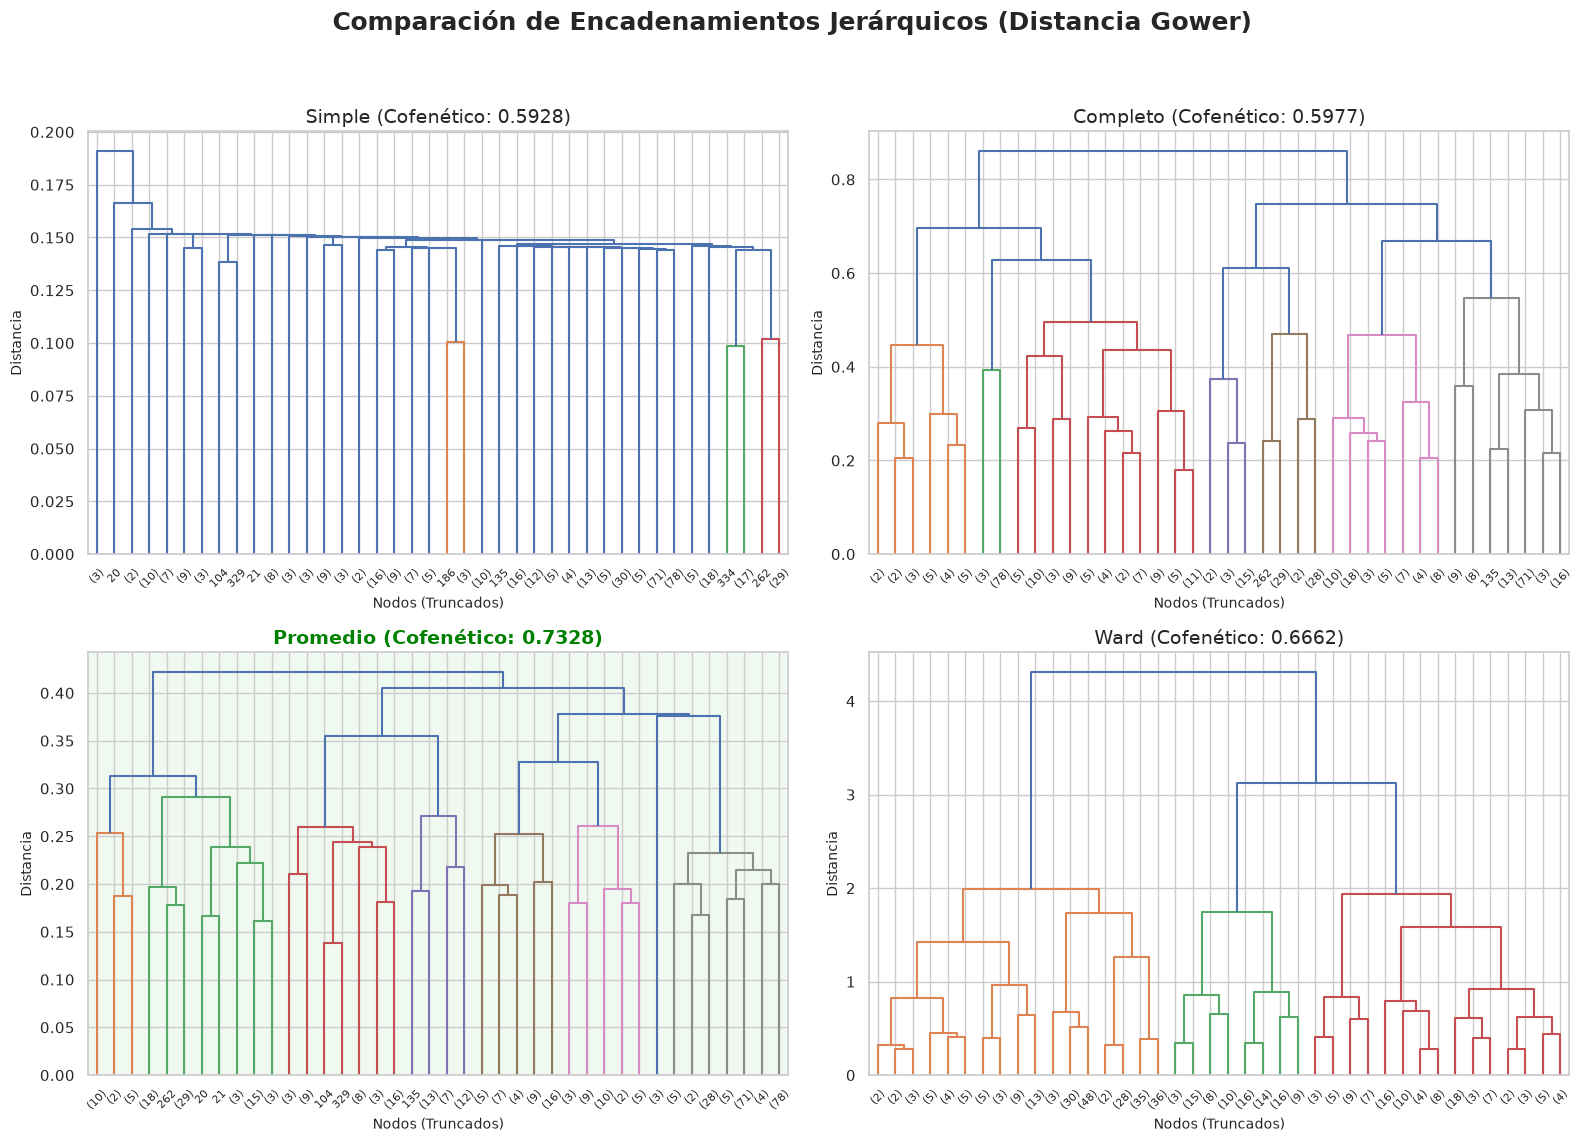

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
import matplotlib.pyplot as plt

# 1. Modelado con distintos métodos de encadenamiento
print("Generando encadenamientos jerárquicos...")
Z_simple = linkage(D_condensada, method='single')
Z_completo = linkage(D_condensada, method='complete')
Z_promedio = linkage(D_condensada, method='average')
Z_ward = linkage(D_condensada, method='ward')

# 2. Evaluación de Calidad (Coeficiente Cofenético)
ccc_simple, _ = cophenet(Z_simple, D_condensada)
ccc_completo, _ = cophenet(Z_completo, D_condensada)
ccc_promedio, _ = cophenet(Z_promedio, D_condensada)
ccc_ward, _ = cophenet(Z_ward, D_condensada)

print("\n--- Coeficientes Cofenéticos ---")
print(f"Encadenamiento Simple:   {ccc_simple:.4f}")
print(f"Encadenamiento Completo: {ccc_completo:.4f}")
print(f"Encadenamiento Promedio: {ccc_promedio:.4f}")
print(f"Método de Ward:          {ccc_ward:.4f}")

# 3. Visualización de la topología (Dendrogramas)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación de Encadenamientos Jerárquicos (Distancia Gower)', fontsize=18, fontweight='bold')

# Configuración de los 4 gráficos
axs[0,0].set_title(f'Simple (Cofenético: {ccc_simple:.4f})', fontsize=14)
dendrogram(Z_simple, ax=axs[0,0], truncate_mode='lastp', p=40)

axs[0,1].set_title(f'Completo (Cofenético: {ccc_completo:.4f})', fontsize=14)
dendrogram(Z_completo, ax=axs[0,1], truncate_mode='lastp', p=40)

axs[1,0].set_title(f'Promedio (Cofenético: {ccc_promedio:.4f})', fontsize=14, color='green', fontweight='bold')
dendrogram(Z_promedio, ax=axs[1,0], truncate_mode='lastp', p=40)
axs[1,0].set_facecolor('#f0f9f0') # Resaltamos el ganador con un fondo sutil

axs[1,1].set_title(f'Ward (Cofenético: {ccc_ward:.4f})', fontsize=14)
dendrogram(Z_ward, ax=axs[1,1], truncate_mode='lastp', p=40)

# Ajustes visuales finales
for ax in axs.flat:
    ax.set_ylabel('Distancia', fontsize=10)
    ax.set_xlabel('Nodos (Truncados)', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### <u> Interpretación Topológica y Selección del Modelo</u> : 


La visualización simultánea de los dendrogramas, en conjunto con sus respectivos coeficientes cofenéticos, expone diferencias estructurales críticas entre los distintos enfoques de aglomeración y justifica de manera objetiva la elección final del modelo:

- El problema del Encadenamiento (Método Simple): Como se observa en el cuadrante superior izquierdo, el método de encadenamiento simple sufre de un severo efecto de chaining (agregación en cadena). Visualmente, esto se traduce en una topología escalonada donde las observaciones se añaden de a una por vez a un único grupo masivo, haciéndolo inútil para propósitos de segmentación comercial. Su coeficiente de 0.5928 confirma esta deficiencia.

- La distorsión Métrica (Métodos Completo y Ward): Si bien los dendrogramas de los métodos Completo y Ward presentan ramificaciones visualmente más esféricas y balanceadas, sus coeficientes cofenéticos (0.5977 y 0.6662, respectivamente) revelan una realidad matemática subyacente: están forzando la estructura de los datos. En particular, la caída en el rendimiento de Ward confirma empíricamente que su diseño de minimización de varianza choca con la naturaleza no euclidiana de la matriz de Gower.

- La Elección Óptima (*Método Promedio*): El encadenamiento Promedio (Average Linkage) se consolida como la única alternativa viable. Alcanza el mayor nivel de fidelidad matemática respecto a las distancias originales (Coeficiente Cofenético de 0.7328) y, visualmente, presenta una topología coherente con la realidad del mercado automotor: identifica grandes troncos o núcleos de vehículos convencionales, mientras aísla tempranamente en ramas distintas a las anomalías multivariadas (vehículos de ultra-lujo o extrema eficiencia).

Por consiguiente, el dendrograma derivado del método Promedio es el seleccionado para realizar el corte de altura y definir los clústeres finales del estudio.

### Determinación del Número Óptimo de Clústeres ($k$)

La definición del número óptimo de clústeres en métodos jerárquicos difiere de enfoques particionales como K-Means. Basándonos en el marco teórico de la métrica a optimizar, debemos descartar técnicas iterativas basadas en la varianza intra-cluster (como el Método del Codo o la Estadística Gap), ya que estas asumen un espacio euclidiano estricto y son compatibles únicamente con el método de Ward.

Dado que nuestro modelo emplea la Distancia de Gower (no euclidiana) y un encadenamiento Promedio, la evaluación del número de grupos ($k$) se fundamentará en dos pilares compatibles con nuestra topología:

- *Inspección Heurística del Dendrograma*: Búsqueda del mayor "salto" o distancia vertical (height) donde no existan uniones, lo cual sugiere una separación natural en los datos.
- *Evaluación Analítica mediante Silhouette Score*: Este indicador mide qué tan similar es un objeto a su propio clúster (cohesión) frente a otros clústeres (separación). Como su cálculo se basa en distancias apareadas, permite utilizar directamente nuestra matriz precalculada de Gower, haciéndolo matemáticamente válido para nuestro modelo.

#### - Silhouette Score

Calculando Silhouette Scores sobre la matriz de Gower...


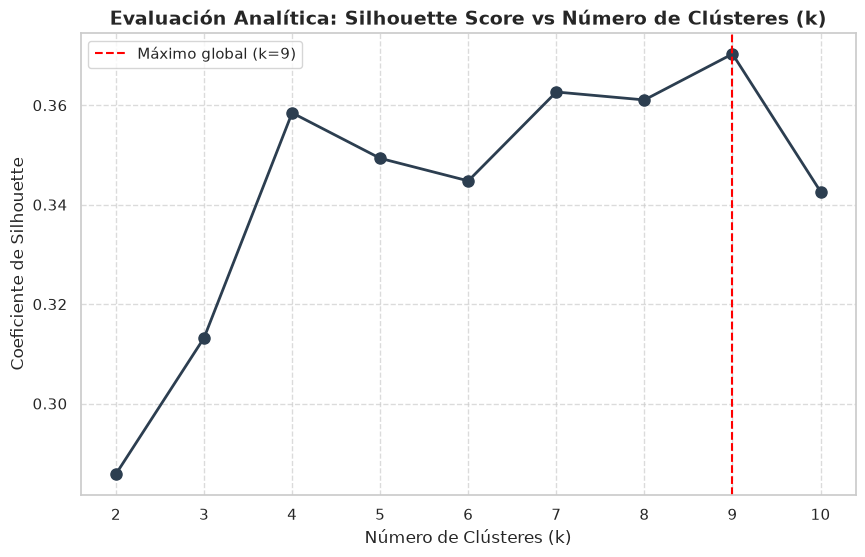

El valor máximo de Silhouette se alcanza con k = 9


In [43]:
import scipy.cluster.hierarchy as sch

rango_k = range(2, 11)
valores_silhouette = []

D_cuadrada = squareform(D_condensada)

print("Calculando Silhouette Scores sobre la matriz de Gower...")

# 3. Iteramos sobre los posibles valores de k
for k in rango_k:
    # Cortamos el dendrograma para forzar 'k' grupos
    etiquetas_k = sch.fcluster(Z_promedio, k, criterion='maxclust')
    
    # Calculamos Silhouette indicando que nuestra matriz ya es de distancias ('precomputed')
    score = silhouette_score(D_cuadrada, etiquetas_k, metric='precomputed')
    valores_silhouette.append(score)

# 4. Visualización de los resultados
plt.figure(figsize=(10, 6))
plt.plot(rango_k, valores_silhouette, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)
plt.title('Evaluación Analítica: Silhouette Score vs Número de Clústeres (k)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('Coeficiente de Silhouette', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltamos el punto máximo
k_optimo = rango_k[valores_silhouette.index(max(valores_silhouette))]
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'Máximo global (k={k_optimo})')
plt.legend()
plt.show()

print(f"El valor máximo de Silhouette se alcanza con k = {k_optimo}")

#### - Corte del dendrograma

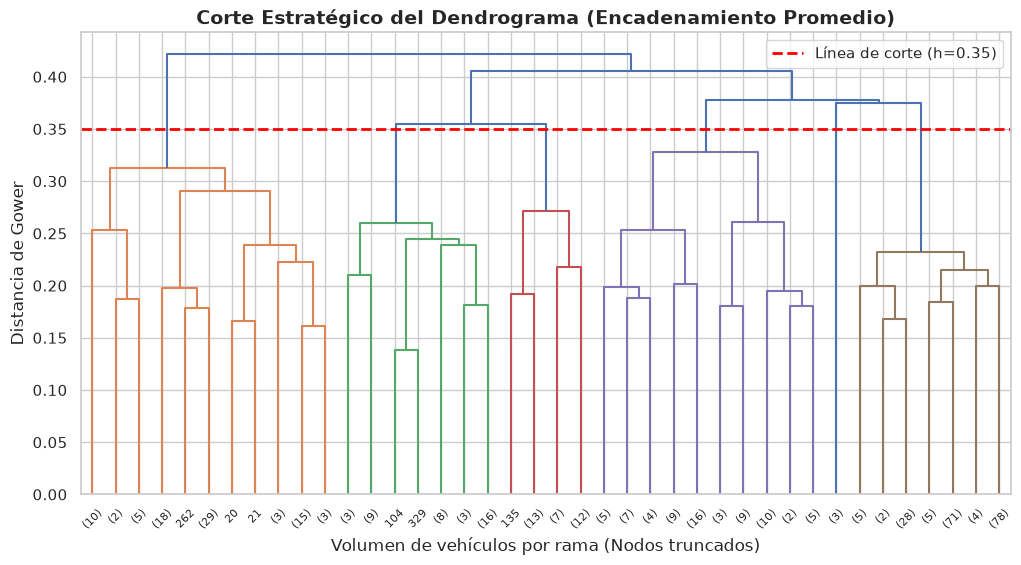

In [44]:
altura_corte = 0.35

plt.figure(figsize=(12, 6))
plt.title('Corte Estratégico del Dendrograma (Encadenamiento Promedio)', fontsize=14, fontweight='bold')
dendrogram(Z_promedio, truncate_mode='lastp', p=40, color_threshold=altura_corte)

plt.axhline(y=altura_corte, color='red', linestyle='--', linewidth=2, label=f'Línea de corte (h={altura_corte})')
plt.ylabel('Distancia de Gower', fontsize=12)
plt.xlabel('Volumen de vehículos por rama (Nodos truncados)', fontsize=12)
plt.legend()
plt.show()

In [45]:
cluster_labels_final = sch.fcluster(Z_promedio, t=altura_corte, criterion='distance')
df['cluster_final'] = cluster_labels_final

print(f"--- Distribución de Clústeres cortando a h={altura_corte} ---")
distribucion_final = df['cluster_final'].value_counts().sort_index()
print(distribucion_final)
print(f"Total de segmentos de mercado generados: {len(distribucion_final)}")

--- Distribución de Clústeres cortando a h=0.35 ---
cluster_final
1     88
2     41
3     33
4     70
5      3
6    193
Name: count, dtype: int64
Total de segmentos de mercado generados: 6


####  <u> Conclusión</u>:

Si bien el coeficiente de Silhouette sugiere un óptimo local en k=9, la inspección topológica del dendrograma y el criterio de aplicabilidad comercial (business rule) indican que un corte en k=6 consolida los micro-segmentos redundantes. De esta forma, evitamos el sobreajuste (over-segmentation) y obtenemos clústeres con un volumen de mercado accionable.

### Proyección y validación visual

   En esta sección, se busca consolidar los resultados obtenidos en el proceso de segmentación jerárquica mediante su proyección sobre el espacio bidimensional generado previamente en el Análisis de Componentes Principales (PCA). El objetivo principal es validar visualmente la coherencia geométrica de las etiquetas asignadas, comprobando cómo el algoritmo ha logrado identificar y delimitar las distintas fronteras comerciales del mercado automotor.

### - Segmentación general sobre Componentes Principales

   Expone la topología global de todos los grupos interactuando en simultáneo

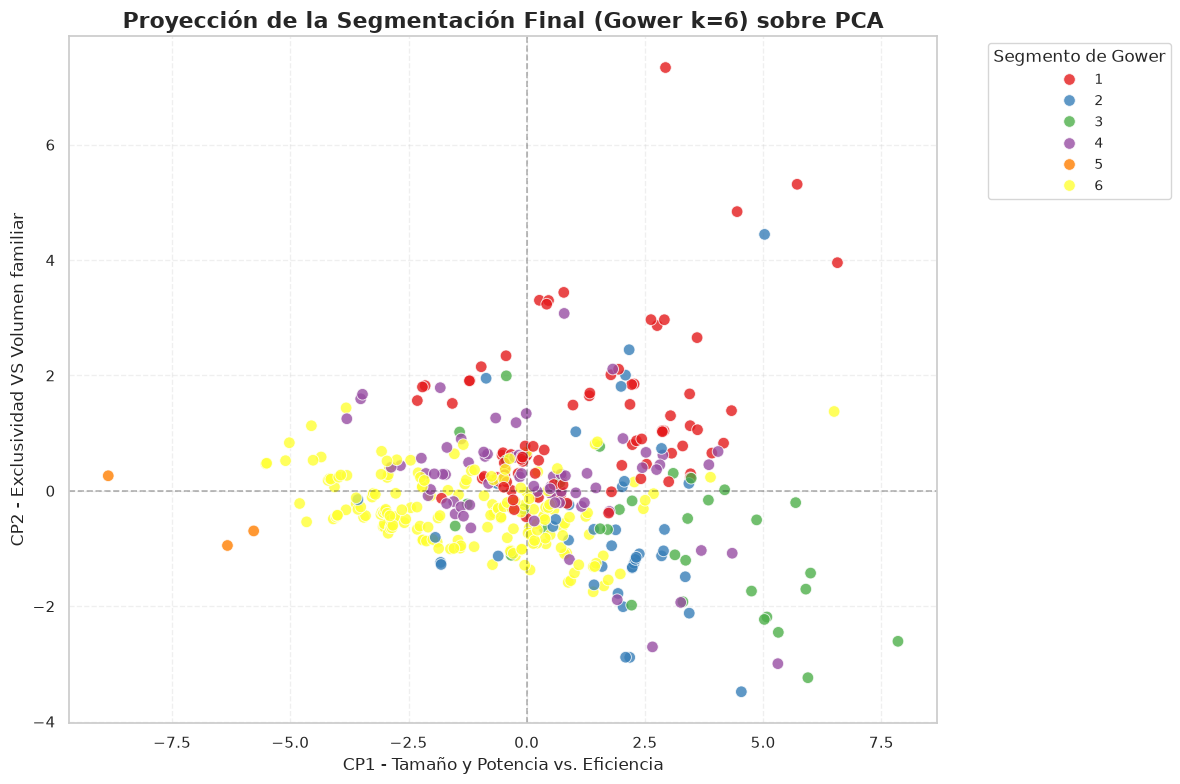

In [46]:
df_scores['cluster_final'] = df['cluster_final']

# 2. Configuración del gráfico
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_scores, 
    x='CP1', 
    y='CP2', 
    hue='cluster_final', 
    palette='Set1',
    s=70, 
    alpha=0.8,
    edgecolor='white'
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.3) 
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.3)

# 5. Estética final
plt.title('Proyección de la Segmentación Final (Gower k=6) sobre PCA', fontsize=16, fontweight='bold')
plt.xlabel('CP1 - Tamaño y Potencia vs. Eficiencia', fontsize=12)
plt.ylabel('CP2 - Exclusividad VS Volumen familiar', fontsize=12)

# Movemos la leyenda afuera para que no tape los puntos
plt.legend(title='Segmento de Gower', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout() # Ajusta los márgenes automáticamente
plt.show()

### - Aislamiento de segmentos
   Evalúa la región de dominancia, la densidad y la dispersión específica de cada clúster sin perder la referencia del resto de los vehículos.

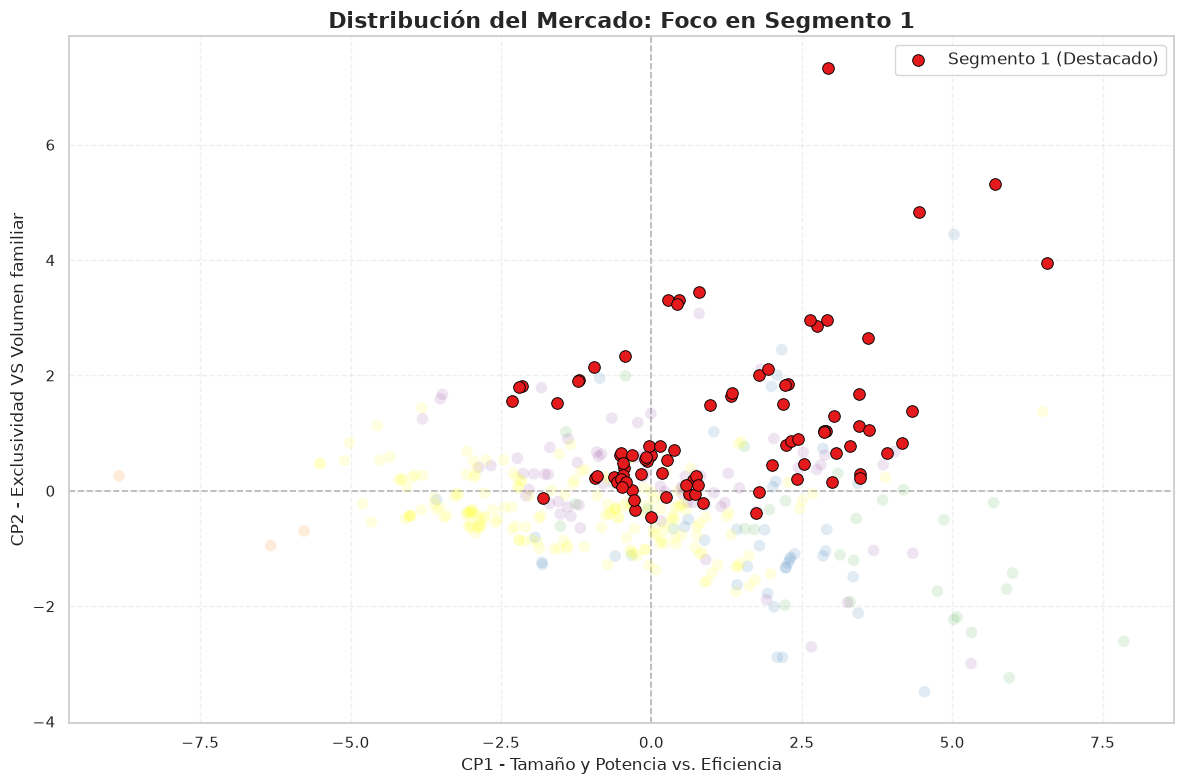

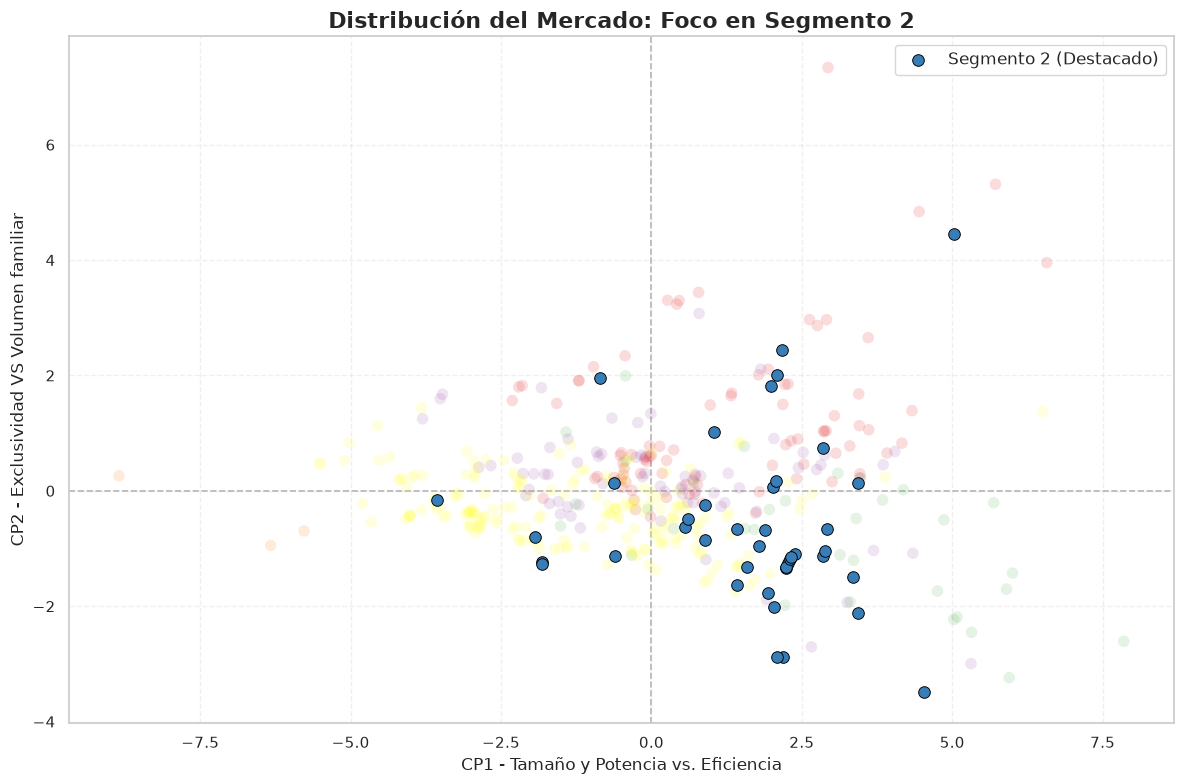

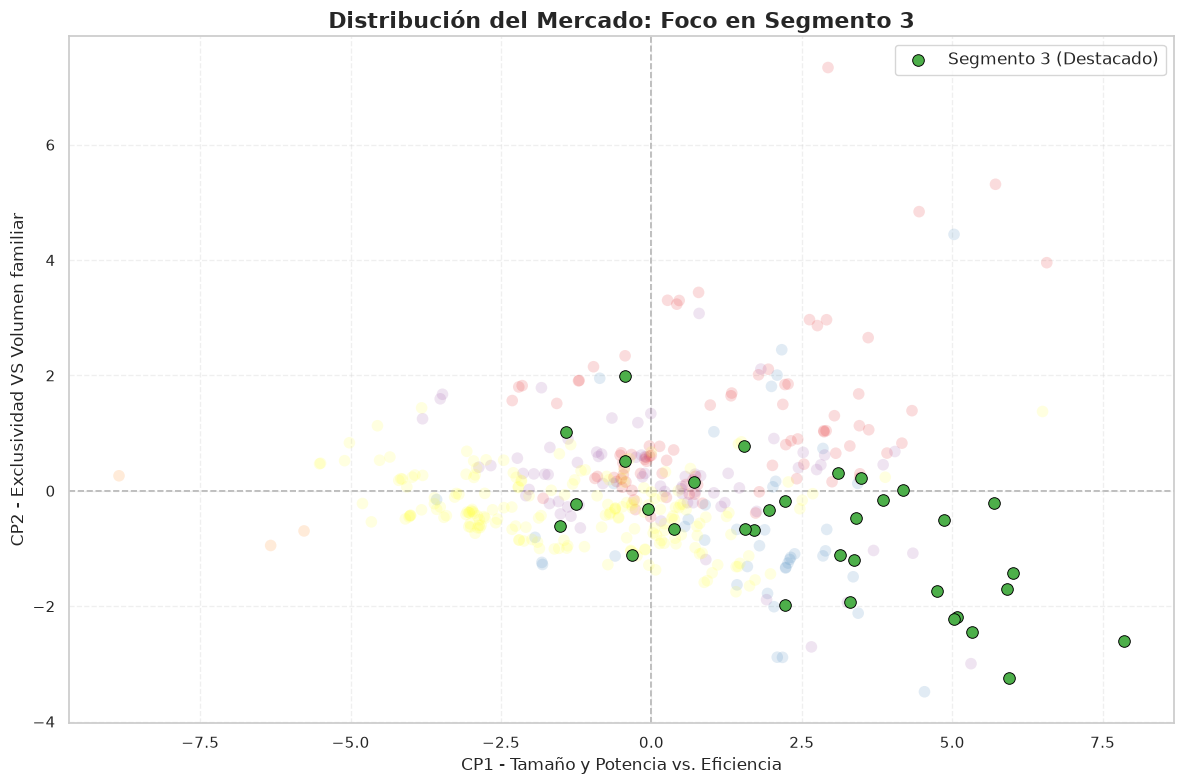

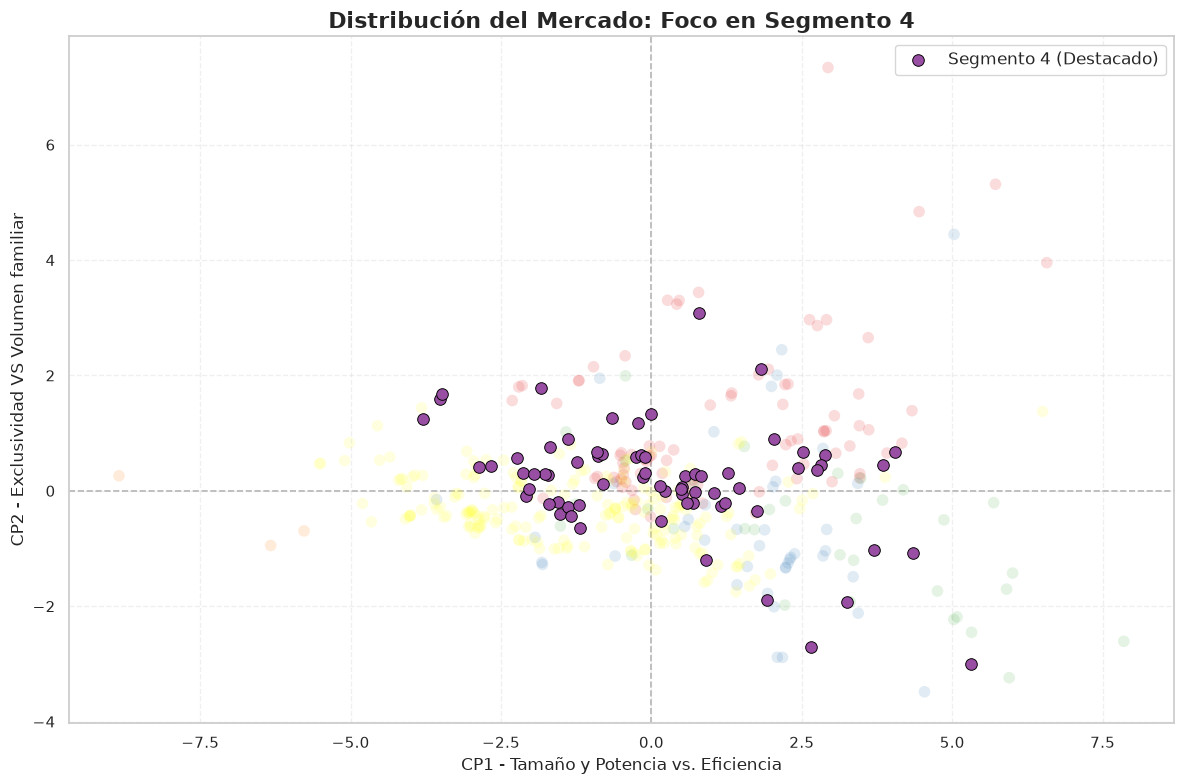

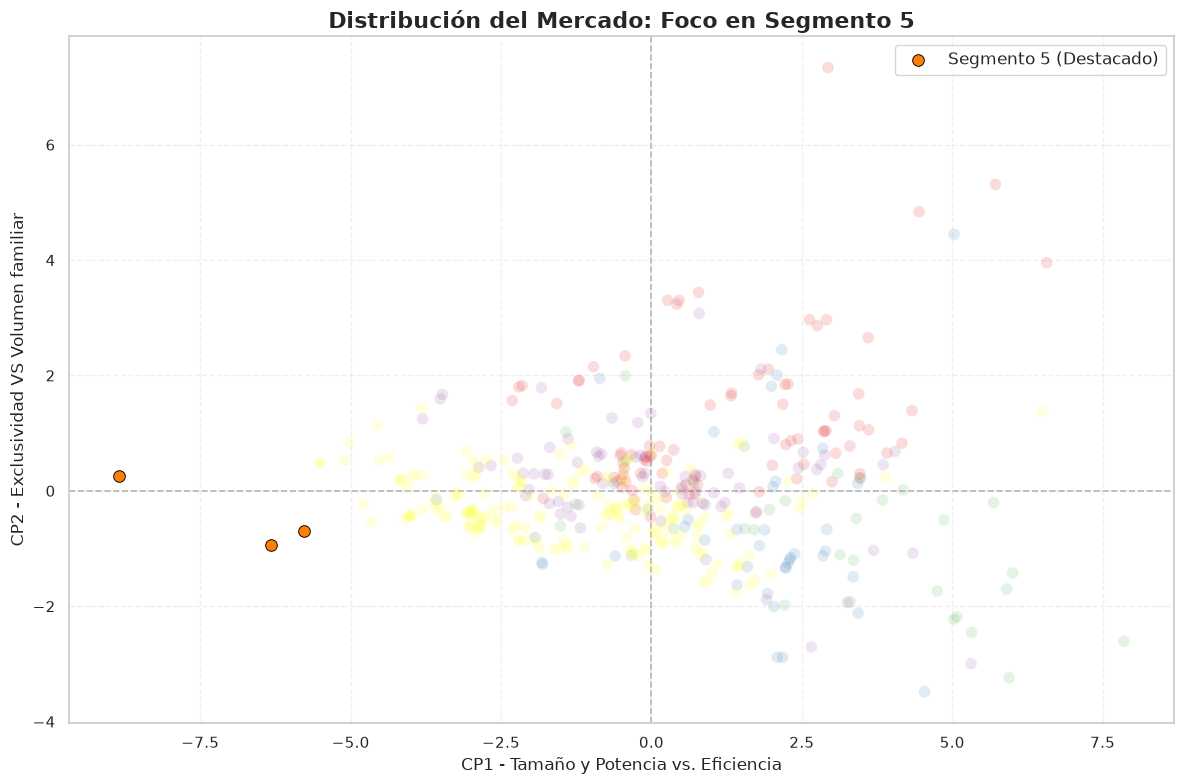

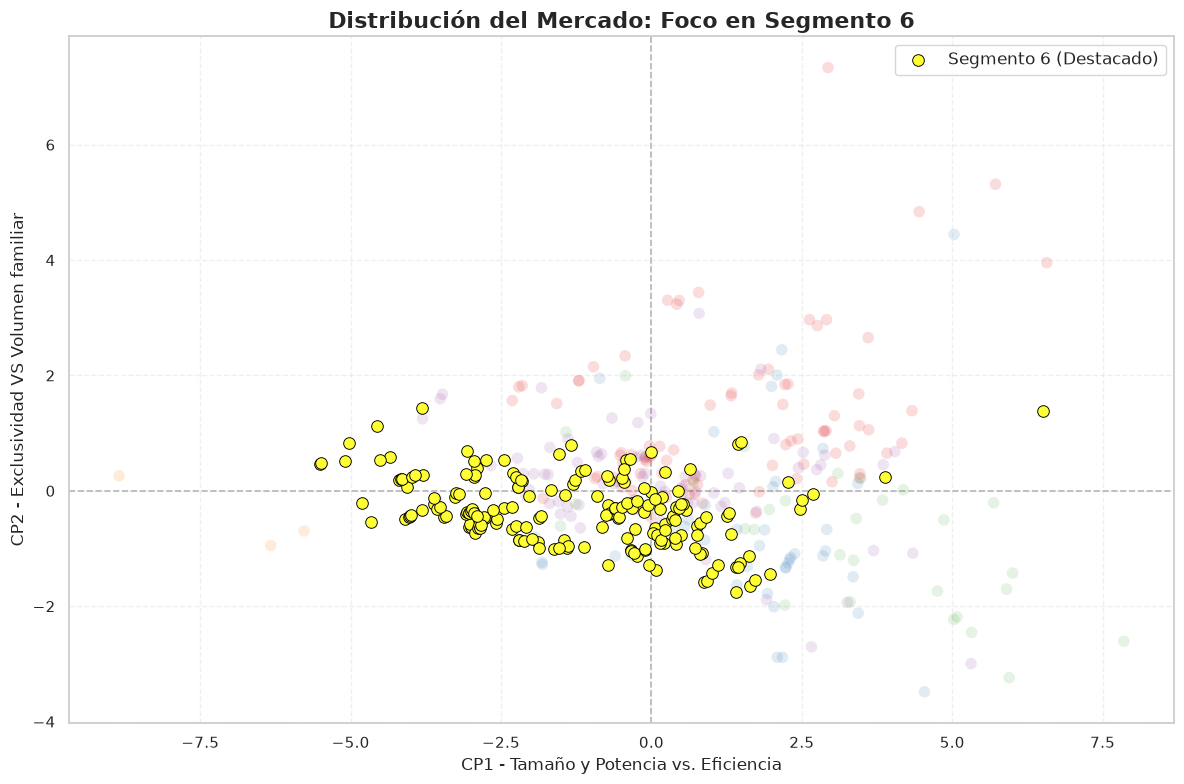

In [47]:
# 1. Definimos los clústeres únicos y aseguramos la paleta de colores original (Set1)
clusters_unicos = sorted(df_scores['cluster_final'].unique())
colores_set1 = sns.color_palette('Set1', n_colors=len(clusters_unicos))
diccionario_colores = dict(zip(clusters_unicos, colores_set1))

# 2. Bucle para generar una diapositiva por cada clúster
for foco in clusters_unicos:
    plt.figure(figsize=(12, 8))
    
    # 3. Dibujamos TODOS los clústeres iterativamente para controlar su opacidad individual
    for c in clusters_unicos:
        df_sub = df_scores[df_scores['cluster_final'] == c]
        
        # Si es el clúster que queremos resaltar: opacidad al 100%, borde blanco y al frente
        if c == foco:
            opacidad = 1.0
            borde = 'black'
            z_order = 5 # Trae los puntos al frente del gráfico
            etiqueta = f'Segmento {c} (Destacado)'
            
        # Si son los otros clústeres: conservan su color, pero casi transparentes y al fondo
        else:
            opacidad = 0.15
            borde = 'none' # Sin borde para que no llamen la atención
            z_order = 1 # Los envía al fondo
            etiqueta = None # Ocultamos sus leyendas para no saturar
            
        sns.scatterplot(
            data=df_sub, 
            x='CP1', 
            y='CP2', 
            color=diccionario_colores[c], 
            s=70,             # El tamaño se mantiene idéntico para absolutamente todos
            alpha=opacidad, 
            edgecolor=borde,
            zorder=z_order,
            label=etiqueta
        )

    # Ejes centrales en línea de puntos (zorder=0 para que queden por detrás de todo)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.3, zorder=0) 
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.3, zorder=0)

    # Estética final
    plt.title(f'Distribución del Mercado: Foco en Segmento {foco}', fontsize=16, fontweight='bold')
    plt.xlabel('CP1 - Tamaño y Potencia vs. Eficiencia', fontsize=12)
    plt.ylabel('CP2 - Exclusividad VS Volumen familiar', fontsize=12)

    # Leyenda y grilla
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(alpha=0.3, linestyle='--', zorder=0)
    plt.tight_layout() 
    
    # Mostramos el gráfico
    plt.show()
    
    # Separador visual en la consola
    print("\n" + "="*156 + "\n")

### Profiling comercial
   
   El objetivo de esta sección es decodificar la estructura interna de cada clúster para transformar las etiquetas numéricas en verdaderos arquetipos comerciales. Mediante un análisis detallado de las medidas de tendencia central, la pureza categórica y la dispersión de las magnitudes, delinearemos el "ADN" de cada segmento.

#### - Resumen de perfiles

A continuación, se presenta la consolidación de las métricas centrales para cada segmento. Esta tabla muestra los promedios de las variables continuas y las modas de las variables cualitativas, funcionando como la hoja de ruta principal para comprender la identidad técnica y el posicionamiento de precio promedio de cada grupo.

In [48]:
profiling_gower = df.groupby('cluster_final').agg({
    'precio_venta': 'mean',                 
    'caballos_fuerza': 'mean',           
    'peso_kg': 'mean',               
    'rendimiento_ciudad_kmL': 'mean',             
    'tipo_vehiculo': lambda x: x.mode()[0] if not x.mode().empty else np.nan, 
    'traccion': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'region_origen': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).round(2)

profiling_gower['Cantidad de autos'] = df['cluster_final'].value_counts()

profiling_gower = profiling_gower.sort_index(ascending=True)

print("--- PERFIL COMERCIAL DE LOS 6 SEGMENTOS (GOWER) ---")
display(profiling_gower)

--- PERFIL COMERCIAL DE LOS 6 SEGMENTOS (GOWER) ---


,precio_venta,caballos_fuerza,peso_kg,rendimiento_ciudad_kmL,tipo_vehiculo,traccion,region_origen,Cantidad de autos
cluster_final,,,,,,,,
1,54242.01,270.94,1713.15,7.52,Sedan,Rear,Europe,88
2,31709.44,238.76,1756.80,7.50,Sedan,Rear,USA,41
3,34505.82,253.00,2135.54,6.52,SUV,All,USA,33
4,30771.80,222.51,1659.73,7.86,SUV,All,Asia,70
5,19920.00,92.00,1129.73,23.40,Hybrid,Front,Asia,3
6,23843.40,179.10,1460.02,9.58,Sedan,Front,Asia,193


#### - Composición categórica

   Para comprender la homogeneidad interna de los segmentos, analizamos la distribución porcentual de sus atributos cualitativos. Estos gráficos revelan cómo el modelo agrupó los vehículos basándose en las distintas variables categóricas utilizadas.

Generando análisis de composición categórica por segmento...



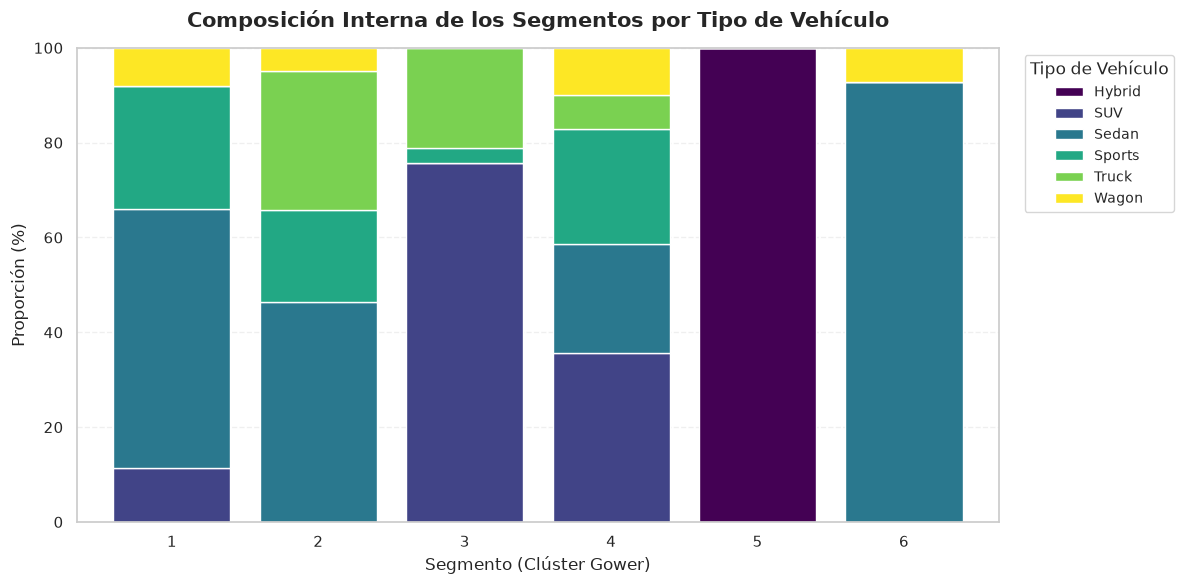

--- DISTRIBUCIÓN PORCENTUAL: TIPO DE VEHÍCULO POR CLÚSTER ---


tipo_vehiculo,Hybrid,SUV,Sedan,Sports,Truck,Wagon
cluster_final,,,,,,
1,0.0,11.4,54.5,26.1,0.0,8.0
2,0.0,0.0,46.3,19.5,29.3,4.9
3,0.0,75.8,0.0,3.0,21.2,0.0
4,0.0,35.7,22.9,24.3,7.1,10.0
5,100.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,92.7,0.0,0.0,7.3


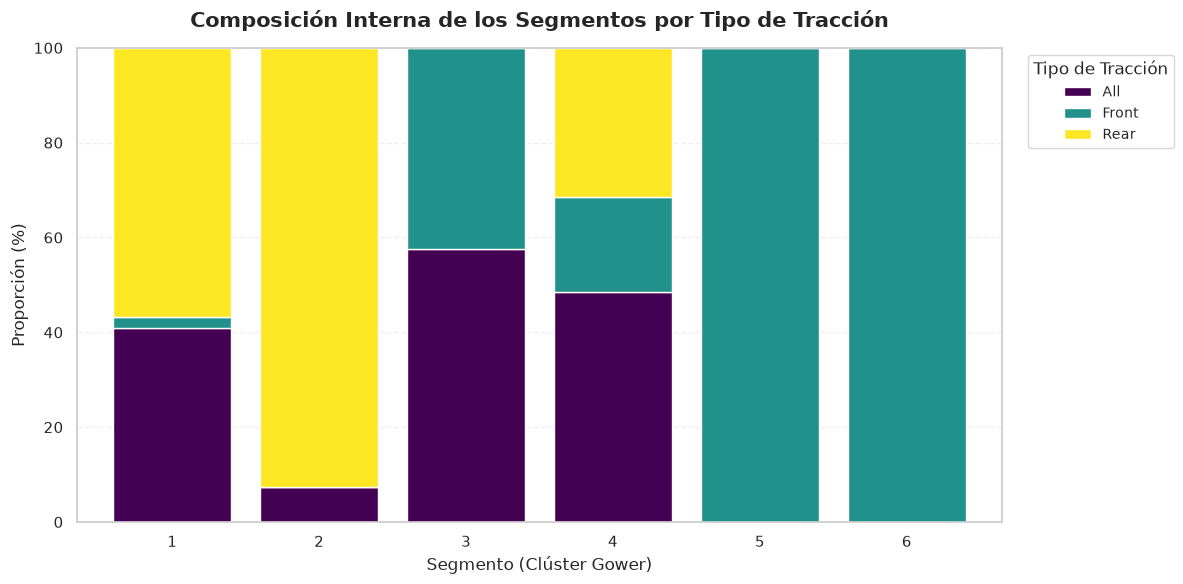

--- DISTRIBUCIÓN PORCENTUAL: TIPO DE TRACCIÓN POR CLÚSTER ---


traccion,All,Front,Rear
cluster_final,,,
1,40.9,2.3,56.8
2,7.3,0.0,92.7
3,57.6,42.4,0.0
4,48.6,20.0,31.4
5,0.0,100.0,0.0
6,0.0,100.0,0.0


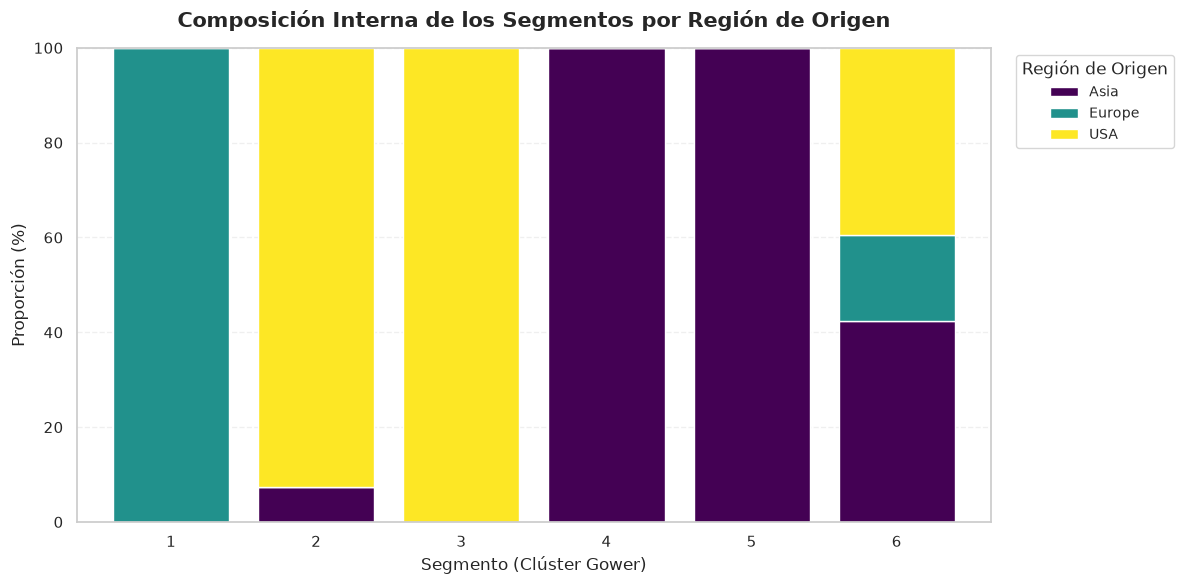

--- DISTRIBUCIÓN PORCENTUAL: REGIÓN DE ORIGEN POR CLÚSTER ---


region_origen,Asia,Europe,USA
cluster_final,,,
1,0.0,100.0,0.0
2,7.3,0.0,92.7
3,0.0,0.0,100.0
4,100.0,0.0,0.0
5,100.0,0.0,0.0
6,42.5,18.1,39.4


In [49]:
# Definimos nuestras variables categóricas y los títulos para que queden prolijos en el gráfico
variables_categoricas = ['tipo_vehiculo', 'traccion', 'region_origen']
nombres_titulos = ['Tipo de Vehículo', 'Tipo de Tracción', 'Región de Origen']

print("Generando análisis de composición categórica por segmento...\n")

# Iteramos sobre cada variable para generar su gráfico y su tabla automáticamente
for var, titulo in zip(variables_categoricas, nombres_titulos):
    
    # 1. Creamos la tabla cruzada (100% apilado por fila)
    crosstab_var = pd.crosstab(df['cluster_final'], df[var], normalize='index') * 100
    
    # 2. Configuración visual del gráfico
    crosstab_var.plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 6), # Un poco más bajo para que entren bien los 3 gráficos en pantalla
        colormap='viridis', 
        edgecolor='white',
        width=0.8
    )
    
    plt.title(f'Composición Interna de los Segmentos por {titulo}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Segmento (Clúster Gower)', fontsize=12)
    plt.ylabel('Proporción (%)', fontsize=12)
    plt.xticks(rotation=0)
    
    # Movemos la leyenda afuera del gráfico
    plt.legend(title=titulo, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 3. Mostrar la tabla exacta para el informe escrito
    print(f"--- DISTRIBUCIÓN PORCENTUAL: {titulo.upper()} POR CLÚSTER ---")
    display(crosstab_var.round(1))
    
    # Separador visual entre cada análisis
    print("\n" + "="*80 + "\n")

El análisis categórico muestra que la región de origen es el principal diferenciador entre clusters. Los clusters 1 a 5 son prácticamente puros en este aspecto: europeos (cluster 1), estadounidenses (clusters 2 y 3) y asiáticos (clusters 4 y 5). El cluster 6 es la excepción, con una mezcla de las tres regiones.

El tipo de vehículo sigue la misma lógica: el cluster 5 agrupa exclusivamente híbridos, el cluster 6 es casi todo Sedan (92,7%), el cluster 3 concentra SUVs y Trucks, y el cluster 1 combina Sedanes con Deportivos. La tracción refuerza estas diferencias: tracción trasera en los clusters americanos y europeos de performance, delantera en los asiáticos y híbridos, y total en los SUVs.

#### - Distribución numérica
  
   Evaluamos la dispersión y los valores atípicos de las variables continuas mediante diagramas de caja (boxplots). Este análisis es fundamental para entender la amplitud de precios dentro de un mismo nicho, los saltos en el rendimiento kilométrico y cómo se distribuye el peso y la potencia a lo largo de las distintas franjas del mercado

Generando análisis de distribución numérica por segmento (Boxplots)...



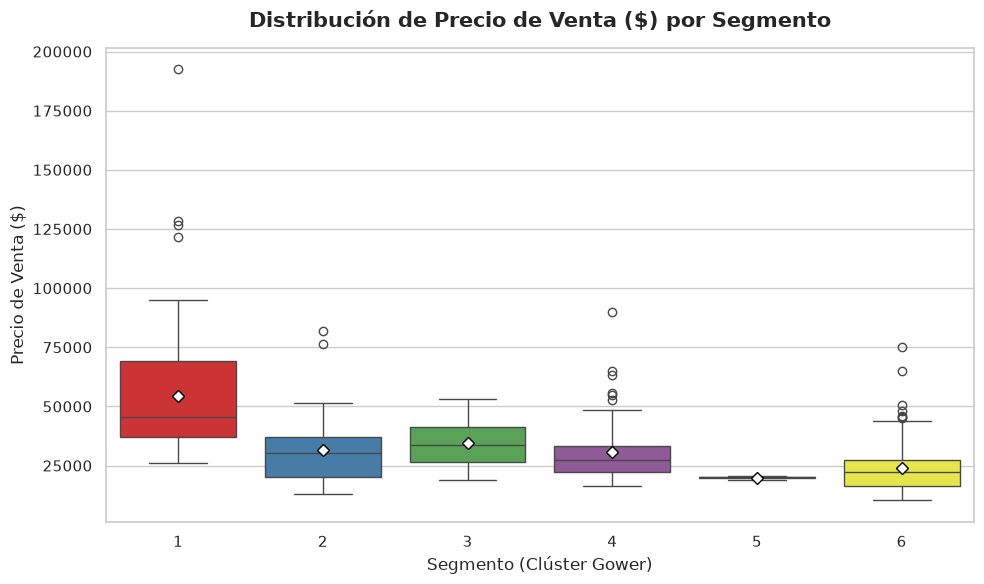

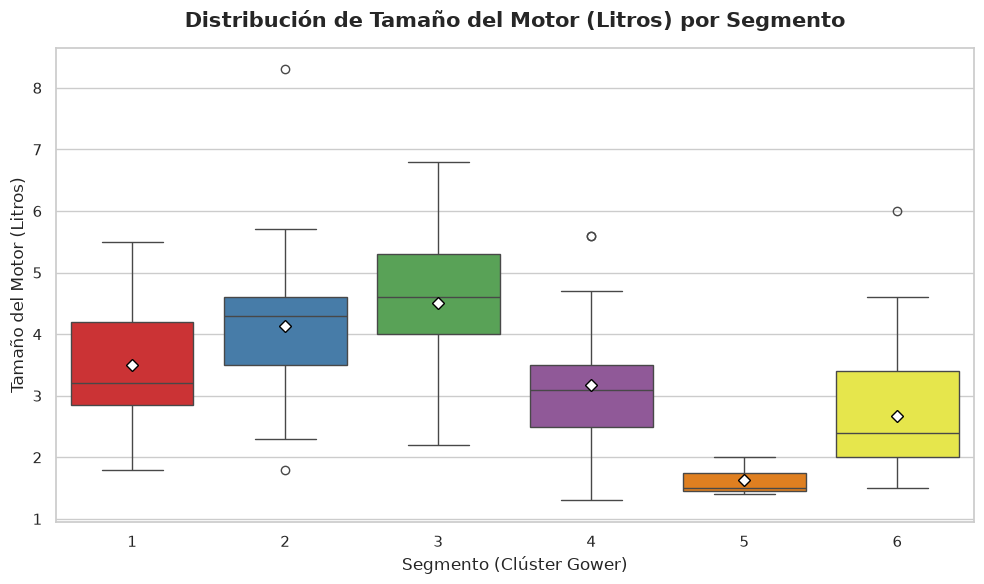

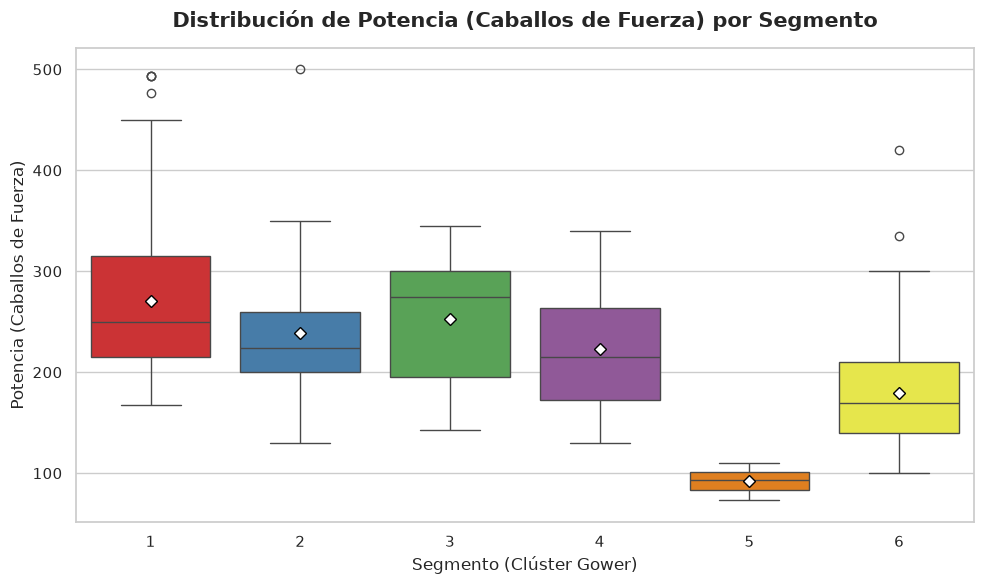

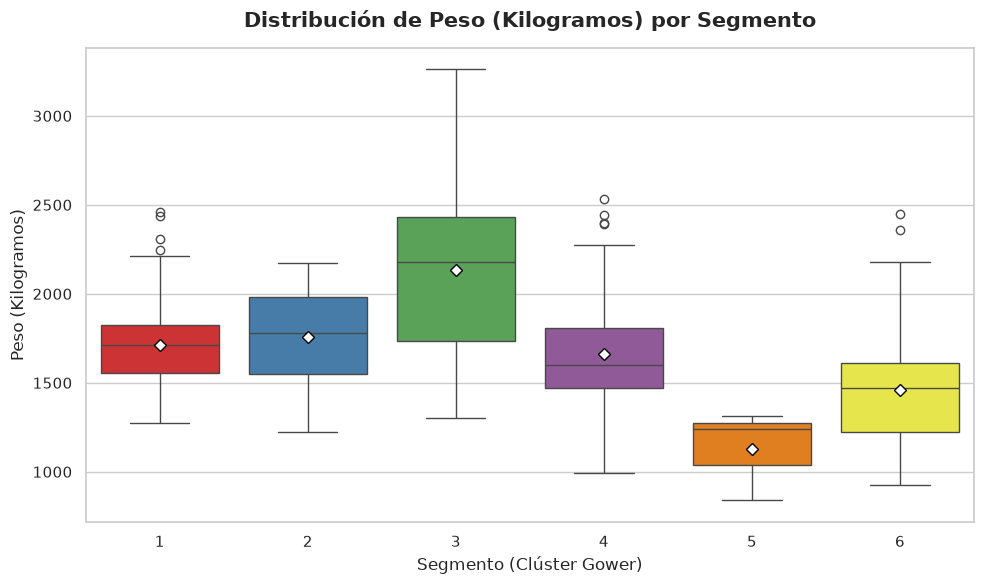

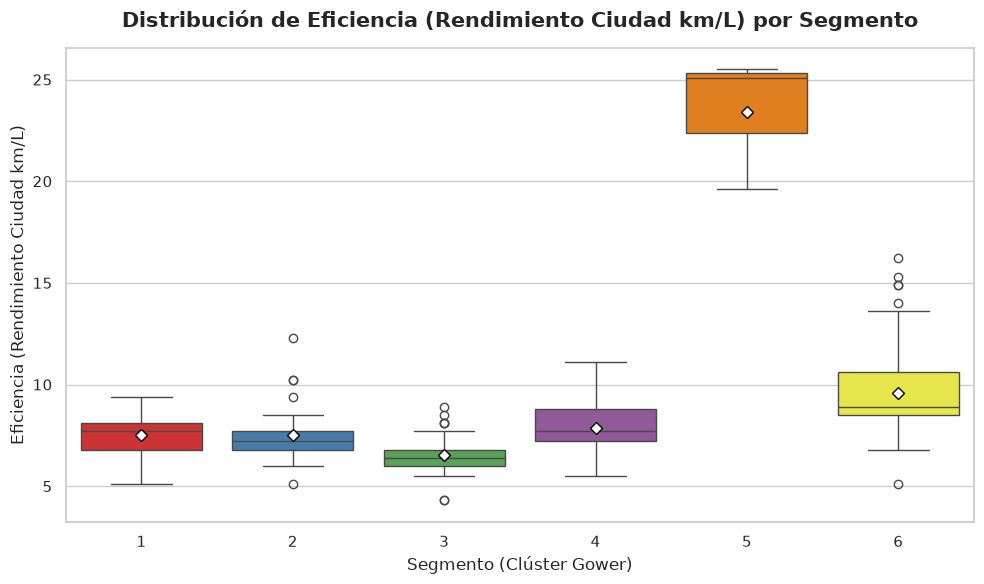

In [50]:
# Definimos nuestras variables numéricas clave y títulos legibles para los ejes
variables_numericas = [
    'precio_venta', 
    'motor_litros', 
    'caballos_fuerza', 
    'peso_kg', 
    'rendimiento_ciudad_kmL'
]

nombres_ejes = [
    'Precio de Venta ($)', 
    'Tamaño del Motor (Litros)', 
    'Potencia (Caballos de Fuerza)', 
    'Peso (Kilogramos)', 
    'Eficiencia (Rendimiento Ciudad km/L)'
]

print("Generando análisis de distribución numérica por segmento (Boxplots)...\n")

# Configuramos un estilo limpio de Seaborn
sns.set_theme(style="whitegrid")

# Iteramos sobre cada variable numérica para generar su boxplot
for var, eje_y in zip(variables_numericas, nombres_ejes):
    
    plt.figure(figsize=(10, 6))
    
    # Creamos el boxplot
    sns.boxplot(
        data=df, 
        x='cluster_final', 
        y=var, 
        hue='cluster_final',
        palette='Set1', 
        legend=False,        
        showmeans=True,  # Agrega un marcador para el promedio (diamante o triángulo)
        meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black"} 
    )
    
    # Configuraciones estéticas del gráfico
    plt.title(f'Distribución de {eje_y} por Segmento', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Segmento (Clúster Gower)', fontsize=12)
    plt.ylabel(eje_y, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*130 + "\n")

<u>Conclusión</u>:

En base a las distribuciones numéricas las diferencias más marcadas entre clusters se dan en precio, potencia y eficiencia. El cluster 1 (europeo) es el más costoso y potente, con un precio medio de USD 54.242 y 271 CV. En el extremo opuesto, el cluster 5 (híbridos asiáticos) tiene el precio más bajo (USD 19.920) y un rendimiento muy superior al resto: 23,4 km/L frente a valores de entre 6,5 y 9,6 en los demás segmentos.

Los clusters americanos (2 y 3) se distinguen por ser los más pesados, especialmente el 3 (2.136 kg), que también registra la menor eficiencia (6,52 km/L), consistente con su composición de SUVs y Trucks. Los clusters asiáticos no híbridos (4 y 6) presentan precios moderados, menor peso y una eficiencia intermedia, conformando el segmento más accesible del mercado.

### Interpretación  de los 6 segmentos

- **Clúster 1** (88 vehículos) - **El Segmento Premium Europeo**: Agrupa a los vehículos de lujo y alta performance. Su identidad está marcada por el origen europeo y la tracción trasera, históricamente asociada a una dinámica de manejo superior. Este segmento se despega del resto al duplicar el precio promedio del mercado ($54,200) y ofrecer el pico máximo de potencia de los grupos mayoritarios (270 HP). Se orientan a un consumidor de alto poder adquisitivo que sacrifica rendimiento en ciudad a cambio de exclusividad y prestaciones deportivas.

- **Clúster 2** (41 vehículos) - **Sedanes de Potencia Americana**: Este nicho agrupa sedanes de origen estadounidense que también utilizan tracción trasera, pero apuntan a un segmento de precio medio ($31,700). Con motores potentes (238 HP) y un peso superior a sus pares asiáticos y europeos (1756 kg), encarnan el clásico sedán americano que prioriza la fuerza bruta en línea recta por sobre la eficiencia (7.50 km/L), orientándose a consumidores que buscan respuesta mecánica sin pagar el costo de los emblemas de lujo europeos.

- **Clúster 3** (33 vehículos) - **Utilitarios y SUVs Pesadas Americanas**: Refleja la filosofía automotriz norteamericana orientada al tamaño extremo. Conformado por SUVs de tracción integral, es el segmento más pesado del mercado (superando largamente las dos toneladas con 2135 kg) y el de peor eficiencia (6.52 km/L). A pesar de su precio elevado ($34,500), su volumen de ventas responde a una demanda específica por capacidad de arrastre, torque elevado (253 HP) y volumen de carga masivo.

- **Clúster 4** (70 vehículos) - **SUVs Multipropósito Asiáticas**: Representa la transición hacia los vehículos familiares versátiles. Son SUVs de tracción integral (AWD) que mantienen un punto de equilibrio comercial sobresaliente: un precio medio de mercado ($30,700), potencia superior a los sedanes estándar (222 HP) y una masa manejable (1659 kg). Es el producto ideal para el segmento familiar que demanda capacidad todoterreno ligera y espacio sin escalar a precios premium.

- **Clúster 5** (3 vehículos) - **La Anomalía Híbrida**: Este micro-segmento valida matemáticamente la robustez del modelo para identificar valores atípicos puros. Se compone de vehículos de origen asiático cuyo diseño orbita exclusivamente en torno a la hiper-eficiencia (23.40 km/L). Para lograrlo, presentan el peso más bajo (1129 kg) y la menor potencia del mercado (92 HP). El algoritmo los aísla correctamente por poseer una "huella técnica" incomparable con el motor de combustión tradicional.

- **Clúster 6** (193 vehículos) - **El Mercado Generalista Asiático**: Constituye el núcleo dominante del parque automotor. Se trata de sedanes de tracción delantera orientados a la practicidad. Su ventaja competitiva radica en el equilibrio: ofrecen el precio de entrada más lógico del mercado masivo (promedio de $23,800), un peso contenido (1460 kg) y una excelente eficiencia de combustible (9.58 km/L) con potencia moderada (179 HP). Representan el estándar del consumidor promedio que busca movilidad económica y confiable.

### Conclusiones de la aplicación de clusters 

La elección de la métrica de Gower con encadenamiento promedio fue determinante para obtener una segmentación coherente. Al trabajar con datos mixtos, este enfoque permitió que variables como el origen o el tipo de vehículo pesaran junto a las numéricas sin distorsionar los resultados. El coeficiente cofenético de 0,73 confirma que la estructura jerárquica representa bien las distancias originales.

Los seis clusters resultantes se diferencian con claridad. En un extremo, el cluster 1 agrupa los vehículos europeos más caros y potentes; en el otro, el cluster 6 reúne la mayoría del mercado masivo con sedanes asiáticos accesibles y eficientes. Los segmentos americanos se destacan por el peso y la tracción trasera, el cluster 4 cubre las SUVs familiares asiáticas a precio medio, y el cluster 5 queda aparte por sus tres híbridos con una eficiencia muy por encima del resto.

En definitiva, la segmentación no es solo estadística: cada grupo tiene sentido desde el punto de vista comercial y refleja lógicas de fabricación y consumo bien distintas entre regiones.